In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import pandas as pd
import numpy as np
import random
import sc_toolbox
import pertpy 

import rpy2.rinterface_lib.callbacks
import anndata2ri
import logging

from rpy2.robjects import pandas2ri
from rpy2.robjects import r

sc.settings.verbosity = 0
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

pandas2ri.activate()
anndata2ri.activate()

pd.set_option('display.max_columns', None)

%load_ext rpy2.ipython

In [2]:
%%R
library(GSA)
library(msigdbr)
library(fgsea)
library(tidyverse) # includes ggplot2, for data visualisation. dplyr, for data manipulation.
library(RColorBrewer) # for a colourful plot

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
%%R

set.seed(42)

# Set up gene lists

In [4]:
%%R
msigdbr_species()

# A tibble: 20 × 2
   species_name                    species_common_name                          
   <chr>                           <chr>                                        
 1 Anolis carolinensis             Carolina anole, green anole                  
 2 Bos taurus                      bovine, cattle, cow, dairy cow, domestic cat…
 3 Caenorhabditis elegans          <NA>                                         
 4 Canis lupus familiaris          dog, dogs                                    
 5 Danio rerio                     leopard danio, zebra danio, zebra fish, zebr…
 6 Drosophila melanogaster         fruit fly                                    
 7 Equus caballus                  domestic horse, equine, horse                
 8 Felis catus                     cat, cats, domestic cat                      
 9 Gallus gallus                   bantam, chicken, chickens, Gallus domesticus 
10 Homo sapiens                    human                                        
11 Macaca

In [5]:
%%R

all_gene_sets = msigdbr(species = "human")
head(all_gene_sets)

# A tibble: 6 × 15
  gs_cat gs_subcat      gs_name        gene_symbol entrez_gene ensembl_gene   
  <chr>  <chr>          <chr>          <chr>             <int> <chr>          
1 C3     MIR:MIR_Legacy AAACCAC_MIR140 ABCC4             10257 ENSG00000125257
2 C3     MIR:MIR_Legacy AAACCAC_MIR140 ABRAXAS2          23172 ENSG00000165660
3 C3     MIR:MIR_Legacy AAACCAC_MIR140 ACTN4                81 ENSG00000130402
4 C3     MIR:MIR_Legacy AAACCAC_MIR140 ACTN4                81 ENSG00000282844
5 C3     MIR:MIR_Legacy AAACCAC_MIR140 ACVR1                90 ENSG00000115170
6 C3     MIR:MIR_Legacy AAACCAC_MIR140 ADAM9              8754 ENSG00000168615
# ℹ 9 more variables: human_gene_symbol <chr>, human_entrez_gene <int>,
#   human_ensembl_gene <chr>, gs_id <chr>, gs_pmid <chr>, gs_geoid <chr>,
#   gs_exact_source <chr>, gs_url <chr>, gs_description <chr>


In [6]:
%%R

# Get the MSigDB collections
collections <- msigdbr_collections()

# Print all rows of the tibble
print(collections, n = Inf)

# A tibble: 23 × 3
   gs_cat gs_subcat         num_genesets
   <chr>  <chr>                    <int>
 1 C1     ""                         299
 2 C2     "CGP"                     3384
 3 C2     "CP"                        29
 4 C2     "CP:BIOCARTA"              292
 5 C2     "CP:KEGG"                  186
 6 C2     "CP:PID"                   196
 7 C2     "CP:REACTOME"             1615
 8 C2     "CP:WIKIPATHWAYS"          664
 9 C3     "MIR:MIRDB"               2377
10 C3     "MIR:MIR_Legacy"           221
11 C3     "TFT:GTRD"                 518
12 C3     "TFT:TFT_Legacy"           610
13 C4     "CGN"                      427
14 C4     "CM"                       431
15 C5     "GO:BP"                   7658
16 C5     "GO:CC"                   1006
17 C5     "GO:MF"                   1738
18 C5     "HPO"                     5071
19 C6     ""                         189
20 C7     "IMMUNESIGDB"             4872
21 C7     "VAX"                      347
22 C8     ""                         7

In [7]:
%%R

#Retrieve human H (hallmark gene sets) 
msigdbr_df <- msigdbr(species = "human", category = "H")


head(msigdbr_df)

# A tibble: 6 × 15
  gs_cat gs_subcat gs_name               gene_symbol entrez_gene ensembl_gene   
  <chr>  <chr>     <chr>                 <chr>             <int> <chr>          
1 H      ""        HALLMARK_ADIPOGENESIS ABCA1                19 ENSG00000165029
2 H      ""        HALLMARK_ADIPOGENESIS ABCB8             11194 ENSG00000197150
3 H      ""        HALLMARK_ADIPOGENESIS ACAA2             10449 ENSG00000167315
4 H      ""        HALLMARK_ADIPOGENESIS ACADL                33 ENSG00000115361
5 H      ""        HALLMARK_ADIPOGENESIS ACADM                34 ENSG00000117054
6 H      ""        HALLMARK_ADIPOGENESIS ACADS                35 ENSG00000122971
# ℹ 9 more variables: human_gene_symbol <chr>, human_entrez_gene <int>,
#   human_ensembl_gene <chr>, gs_id <chr>, gs_pmid <chr>, gs_geoid <chr>,
#   gs_exact_source <chr>, gs_url <chr>, gs_description <chr>


In [8]:
%%R

pathwaysH = split(x = msigdbr_df$gene_symbol, f = msigdbr_df$gs_name)
head(pathwaysH)

$HALLMARK_ADIPOGENESIS
  [1] "ABCA1"    "ABCB8"    "ACAA2"    "ACADL"    "ACADM"    "ACADS"   
  [7] "ACLY"     "ACO2"     "ACOX1"    "ADCY6"    "ADIG"     "ADIPOQ"  
 [13] "ADIPOR2"  "ADIPOR2"  "AGPAT3"   "AIFM1"    "AK2"      "ALDH2"   
 [19] "ALDOA"    "ANGPT1"   "ANGPTL4"  "APLP2"    "APOE"     "ARAF"    
 [25] "ARL4A"    "ATL2"     "ATP1B3"   "ATP5PO"   "BAZ2A"    "BCKDHA"  
 [31] "BCL2L13"  "BCL6"     "C3"       "CAT"      "CAVIN1"   "CAVIN2"  
 [37] "CCNG2"    "CD151"    "CD302"    "CD36"     "CDKN2C"   "CHCHD10" 
 [43] "CHCHD10"  "CHCHD10"  "CHUK"     "CIDEA"    "CMBL"     "CMPK1"   
 [49] "COL15A1"  "COL4A1"   "COQ3"     "COQ5"     "COQ9"     "COX6A1"  
 [55] "COX7B"    "COX8A"    "CPT2"     "CRAT"     "CS"       "CYC1"    
 [61] "CYP4B1"   "DBT"      "DDT"      "DDT"      "DECR1"    "DGAT1"   
 [67] "DGAT1"    "DGAT1"    "DHCR7"    "DHRS7"    "DHRS7B"   "DLAT"    
 [73] "DLD"      "DNAJB9"   "DNAJC15"  "DRAM2"    "ECH1"     "ECH1"    
 [79] "ECHS1"    "ELMOD3"   "ELOVL6"   "E

In [9]:
%%R

options(ports=8888)

# NAWM_MOL

In [10]:
%%R

# Replace the file path with the actual path if the file is not in the current directory
df <- read.csv("./files/GLMM_full_results_with_quality_NAWMvWM_MG_noPVM_cleaned.csv")
head(df)  # Display the first few rows of the data frame to confirm it's loaded correctly

       gene   logFC_WM         se       pvalue convergence pdHess    logLik
1 HIST2H2BE  1.3295259 0.19016438 2.720480e-12           0   TRUE -105.2346
2     DOCK8  0.4484780 0.06322745 1.311491e-12           0   TRUE -189.8220
3     CGNL1  2.2215919 0.31731286 2.536592e-12           0   TRUE -109.9693
4   STARD13 -1.1010678 0.16679494 4.074953e-11           0   TRUE -168.9946
5      PKN2  0.3130996 0.04791966 6.410276e-11           0   TRUE -146.2384
6    YTHDC2  0.3593009 0.05502442 6.583801e-11           0   TRUE -120.3624
       AIC error          FDR status
1 228.4692    NA 5.300403e-09     OK
2 397.6440    NA 5.300403e-09     OK
3 237.9385    NA 5.300403e-09     OK
4 355.9893    NA 6.805172e-08     OK
5 310.4769    NA 8.551626e-08     OK
6 258.7248    NA 8.551626e-08     OK


In [11]:
%%R

df <- df %>%
  mutate(logFC_rev = logFC_WM * -1)

In [12]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_up <- df[df$FDR < 0.05 & df$logFC_rev > 0.585, ]
num_genes_up <- nrow(genes_up)

# Print the number of significant genes
print(num_genes_up)

genes_up_sorted <- genes_up[order(genes_up$logFC_rev, decreasing = TRUE), ]

# View the head of the significant genes data frame
head(genes_up_sorted)

[1] 228
       gene  logFC_WM        se       pvalue convergence pdHess     logLik
592   CSMD1 -8.378747 2.7990163 2.758325e-03           0   TRUE  -49.63344
162 FAM135B -4.967009 1.2083353 3.945963e-05           0   TRUE  -69.64470
331   SHOX2 -4.571482 1.2946713 4.139942e-04           0   TRUE  -49.17972
236   TRHDE -4.288330 1.1108562 1.132095e-04           0   TRUE  -73.12490
220   CD163 -4.268989 1.0937358 9.495814e-05           0   TRUE -116.10460
159   S100B -3.617162 0.8742489 3.511842e-05           0   TRUE  -44.78577
         AIC error         FDR status logFC_rev
592 117.2669    NA 0.040205516     OK  8.378747
162 157.2894    NA 0.002059299     OK  4.967009
331 116.3594    NA 0.010765483     OK  4.571482
236 164.2498    NA 0.004183295     OK  4.288330
220 250.2092    NA 0.003750205     OK  4.268989
159 107.5715    NA 0.001866065     OK  3.617162


In [13]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_down <- df[df$FDR < 0.05 & df$logFC_rev < -0.585, ]
num_genes_down <- nrow(genes_down)

# Print the number of significant genes
print(num_genes_down)

genes_down_sorted <- genes_down[order(genes_down$logFC_rev, decreasing = FALSE), ]

# View the head of the significant genes data frame
head(genes_down_sorted)

[1] 114
          gene logFC_WM        se       pvalue convergence pdHess     logLik
466      HCG22 3.710426 1.1633239 1.425171e-03           0   TRUE -107.17847
571  LINC00958 2.728354 0.9033669 2.526028e-03           0   TRUE  -58.36448
3        CGNL1 2.221592 0.3173129 2.536592e-12           0   TRUE -109.96927
213    CYP26C1 2.120397 0.5403295 8.699424e-05           0   TRUE  -66.36281
445  LINC01845 2.082573 0.6425491 1.190650e-03           0   TRUE  -62.81320
348 AL139351.2 2.063082 0.5917403 4.894485e-04           0   TRUE  -78.71953
         AIC error          FDR status logFC_rev
466 232.3569    NA 2.605682e-02     OK -3.710426
571 134.7290    NA 3.805319e-02     OK -2.728354
3   237.9385    NA 5.300403e-09     OK -2.221592
213 150.7256    NA 3.531120e-03     OK -2.120397
445 143.6264    NA 2.281755e-02     OK -2.082573
348 175.4391    NA 1.217373e-02     OK -2.063082


In [14]:
%%R

dim(df)

[1] 8739   12


In [15]:
%%R

my_genes <- df$gene
head(my_genes)

[1] "HIST2H2BE" "DOCK8"     "CGNL1"     "STARD13"   "PKN2"      "YTHDC2"   


In [16]:
%%R
# Check column names in the dataframe
colnames(df)

 [1] "gene"        "logFC_WM"    "se"          "pvalue"      "convergence"
 [6] "pdHess"      "logLik"      "AIC"         "error"       "FDR"        
[11] "status"      "logFC_rev"  


In [17]:
%%R

df <- df[!is.na(df$pvalue) & !is.na(df$logFC_rev), ]
dim(df)

[1] 8739   12


In [18]:
%%R

# Start with the original dataframe
clean_df <- df

# Replace p-values of exactly 0 with a very small number
# Using machine epsilon * 10 to avoid numerical issues
min_pvalue <- .Machine$double.eps * 10
clean_df$pvalue[clean_df$pvalue == 0] <- min_pvalue

# Calculate Z-score from unadjusted p-value and log fold change sign
# Z-score = qnorm(p/2, lower.tail=FALSE) * sign(logFC)
# Using p/2 for two-tailed test conversion
clean_df$z_score <- qnorm(clean_df$pvalue/2, lower.tail = FALSE) * sign(clean_df$logFC_rev)

# Create rankings for FGSEA
rankings <- clean_df$z_score
names(rankings) <- clean_df$gene

# Remove any remaining NA or infinite values that might have been created
rankings <- rankings[is.finite(rankings)]

# Sort the rankings in descending order
rankings <- sort(rankings, decreasing = TRUE)

# Optional: Check the distribution of your rankings
print(paste("Number of genes in ranking:", length(rankings)))
print(paste("Range of Z-scores:", round(min(rankings), 2), "to", round(max(rankings), 2)))
print(head(rankings, 10))  # Show top 10 genes

[1] "Number of genes in ranking: 8739"
[1] "Range of Z-scores: -7.09 to 6.6"
   STARD13 AP002991.1     FNDC3B      APOC1       ATG7       MITF      CDK14 
  6.601326   6.302630   6.145815   6.134776   6.121052   5.937019   5.546333 
      CD44   ARHGAP10      MCTP1 
  5.526415   5.439978   5.340706 


In [19]:
%%R

# Ensure the length of the gene column matches the length of rankings
length(df$gene) == length(rankings)

[1] TRUE


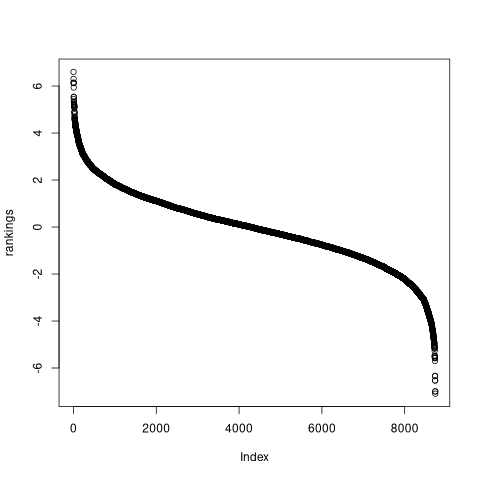

In [20]:
%%R

plot(rankings)

In [21]:
%%R

max(rankings)

[1] 6.601326


In [22]:
%%R

min(rankings)

[1] -7.093091


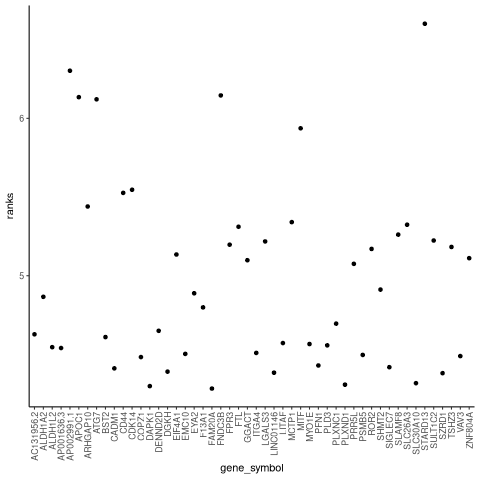

In [23]:
%%R

ggplot(data.frame(gene_symbol = names(rankings)[1:50], ranks = rankings[1:50]), aes(gene_symbol, ranks)) + 
    geom_point() +
    theme_classic() + 
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

# Figure out how to set up gene lists

In [24]:
%%R
fgsea_res <- fgsea(pathways = pathwaysH, 
                  stats    = rankings,
                  scoreType = 'std',
                  minSize  = 15,
                  maxSize  = 500)

In [25]:
%%R
fgsea_res

                                       pathway         pval         padj
                                        <char>        <num>        <num>
 1:                      HALLMARK_ADIPOGENESIS 1.778801e-02 5.718144e-02
 2:               HALLMARK_ALLOGRAFT_REJECTION 1.352560e-02 5.297528e-02
 3:                 HALLMARK_ANDROGEN_RESPONSE 3.445946e-01 4.152807e-01
 4:                      HALLMARK_ANGIOGENESIS 2.484211e-01 3.538118e-01
 5:                   HALLMARK_APICAL_JUNCTION 2.481752e-01 3.538118e-01
 6:                         HALLMARK_APOPTOSIS 2.667568e-02 7.375042e-02
 7:              HALLMARK_BILE_ACID_METABOLISM 6.807512e-01 7.110068e-01
 8:           HALLMARK_CHOLESTEROL_HOMEOSTASIS 1.990847e-01 3.018380e-01
 9:                       HALLMARK_COAGULATION 5.283427e-04 3.547444e-03
10:                        HALLMARK_COMPLEMENT 9.398283e-06 1.677444e-04
11:                        HALLMARK_DNA_REPAIR 1.038647e-01 1.952657e-01
12:                       HALLMARK_E2F_TARGETS 5.34

In [26]:
%%R

dim(fgsea_res)

[1] 47  8


In [27]:
%%R
library(data.table)

#fwrite(fgsea_res, file = "./files/fgsea_ALvWM_GvC_all.csv")

data.table 1.16.4 using 24 threads (see ?getDTthreads).  Latest news: r-datatable.com

Attaching package: ‘data.table’

The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year

The following objects are masked from ‘package:dplyr’:

    between, first, last

The following object is masked from ‘package:purrr’:

    transpose



In [28]:
%%R

# Filter for significant results with padj < 0.05
fgsea_MOL2_significant <- fgsea_res %>% filter(padj < 0.1)
dim(fgsea_MOL2_significant)

[1] 19  8


In [29]:
%%R

head(fgsea_MOL2_significant)

                                      pathway         pval         padj
                                       <char>        <num>        <num>
1:                      HALLMARK_ADIPOGENESIS 1.778801e-02 0.0571814359
2:               HALLMARK_ALLOGRAFT_REJECTION 1.352560e-02 0.0529752834
3:                         HALLMARK_APOPTOSIS 2.667568e-02 0.0737504155
4:                       HALLMARK_COAGULATION 5.283427e-04 0.0035474436
5:                        HALLMARK_COMPLEMENT 9.398283e-06 0.0001677444
6: HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION 1.070709e-05 0.0001677444
     log2err        ES      NES  size                             leadingEdge
       <num>     <num>    <num> <int>                                  <list>
1: 0.3524879 0.3250005 1.437204   106    ABCA1,PPARG,LPL,CD151,PIM3,HIBCH,...
2: 0.3807304 0.3349879 1.443434    91   FCGR2B,GPR65,IL15,CAPG,LCP2,TGFB2,...
3: 0.3524879 0.3403900 1.421484    76    CD44,LGALS3,HGF,CASP7,TGFB2,FEZ1,...
4: 0.4772708 0.4767187 1.896754   

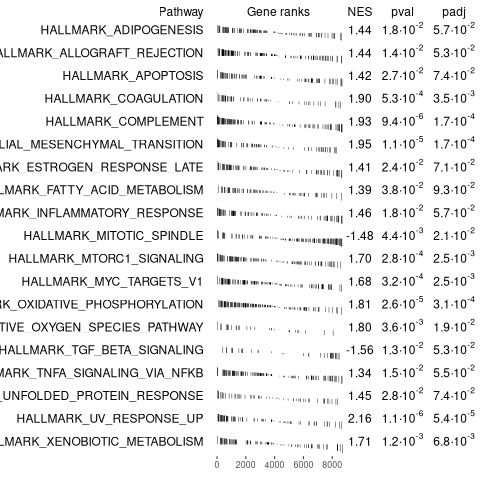

In [30]:
%%R

plotGseaTable(pathwaysH[fgsea_MOL2_significant$pathway], 
              rankings, 
              fgsea_MOL2_significant, 
              gseaParam = 0.5)

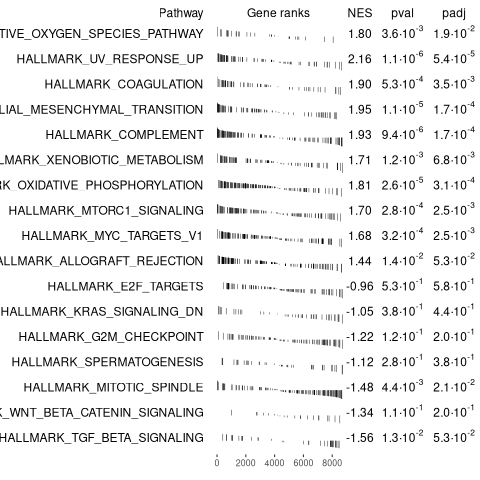

In [31]:
%%R

topUp <- fgsea_res %>% 
    filter(ES > 0) %>% 
    top_n(10, wt=-padj)
topDown <- fgsea_res %>% 
    filter(ES < 0) %>% 
    top_n(10, wt=-padj)
topPathways <- bind_rows(topUp, topDown) %>% 
    arrange(-ES)
plotGseaTable(pathwaysH[topPathways$pathway], 
              rankings, 
              fgsea_res, 
              gseaParam = 0.5)

In [32]:
%%R

collapsedPathways <- collapsePathways(fgsea_MOL2_significant[order(pval)][padj < 0.1], 
                                      pathwaysH, rankings)

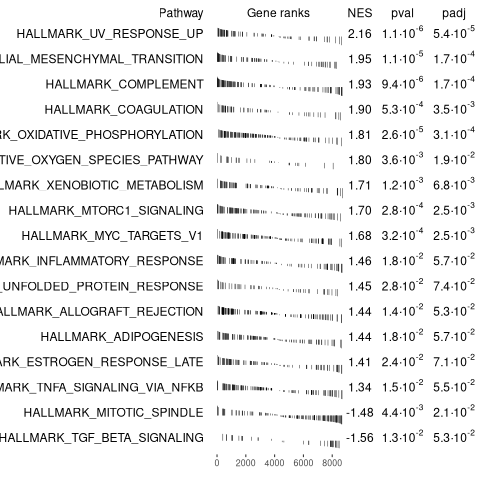

In [33]:
%%R

mainPathways <- fgsea_MOL2_significant[pathway %in% collapsedPathways$mainPathways][
                         order(-NES), pathway]
plotGseaTable(pathwaysH[mainPathways], rankings, fgsea_MOL2_significant, 
              gseaParam = 0.5)

In [34]:
%%R

fgseaResTidy <- fgsea_res %>%
  as_tibble() %>%
  arrange(desc(NES))

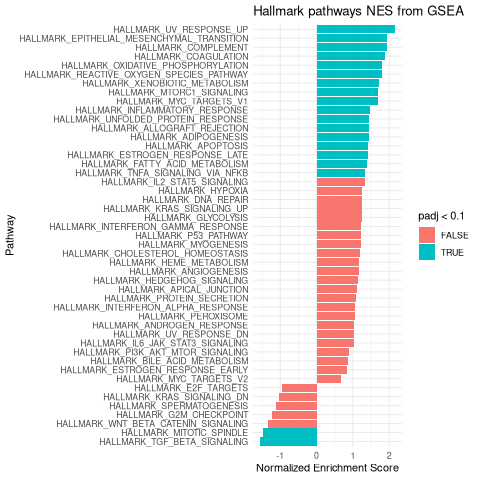

In [35]:
%%R

ggplot(fgseaResTidy, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill=padj<0.1)) +
  coord_flip() +
  labs(x="Pathway", y="Normalized Enrichment Score",
       title="Hallmark pathways NES from GSEA") + 
  theme_minimal()


#https://stephenturner.github.io/deseq-to-fgsea/#using_the_fgsea_package

In [36]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.1, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                         padj   NES  size
  <chr>                                          <dbl> <dbl> <int>
1 HALLMARK_UV_RESPONSE_UP                    0.0000540  2.16    71
2 HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION 0.000168   1.95    80
3 HALLMARK_COMPLEMENT                        0.000168   1.93   100
4 HALLMARK_OXIDATIVE_PHOSPHORYLATION         0.000307   1.81   133
5 HALLMARK_MTORC1_SIGNALING                  0.00251    1.70   109
6 HALLMARK_MYC_TARGETS_V1                    0.00251    1.68   112


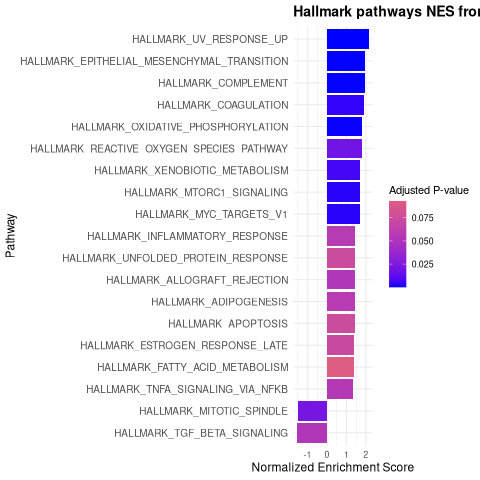

In [37]:
%%R

# Create the ggplot with a color scale for padj
ggplot(fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

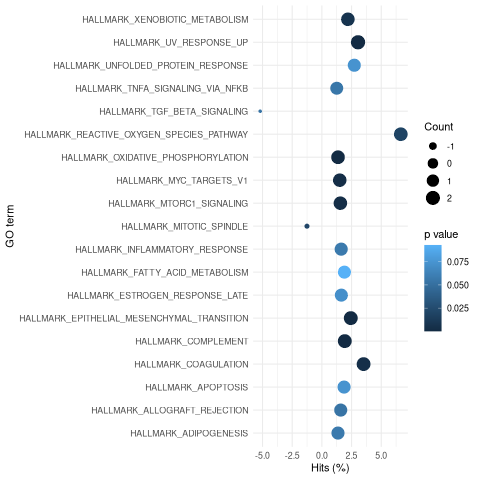

In [38]:
%%R

# Calculate hits percentage (if 'numDEInCat' and 'numInCat' equivalent are 'NES' and 'size')
fgseaResSignificant <- fgseaResSignificant %>%
  mutate(hitsPerc = NES * 100 / size)

# Ensure the columns 'padj' and 'NES' are present for the plot
fgseaResSignificant <- fgseaResSignificant %>%
  rename(term = pathway, over_represented_pvalue = padj, numDEInCat = NES)

# Create the plot
ggplot(fgseaResSignificant, aes(x = hitsPerc, y = term, colour = over_represented_pvalue, size = numDEInCat)) +
  geom_point() +
  expand_limits(x = 0) +
  labs(x = "Hits (%)", y = "GO term", colour = "p value", size = "Count") +
  theme_minimal()

#https://bioinformatics-core-shared-training.github.io/cruk-summer-school-2018/RNASeq2018/html/06_Gene_set_testing.nb.html

In [39]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.1, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                         padj   NES  size
  <chr>                                          <dbl> <dbl> <int>
1 HALLMARK_UV_RESPONSE_UP                    0.0000540  2.16    71
2 HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION 0.000168   1.95    80
3 HALLMARK_COMPLEMENT                        0.000168   1.93   100
4 HALLMARK_OXIDATIVE_PHOSPHORYLATION         0.000307   1.81   133
5 HALLMARK_MTORC1_SIGNALING                  0.00251    1.70   109
6 HALLMARK_MYC_TARGETS_V1                    0.00251    1.68   112


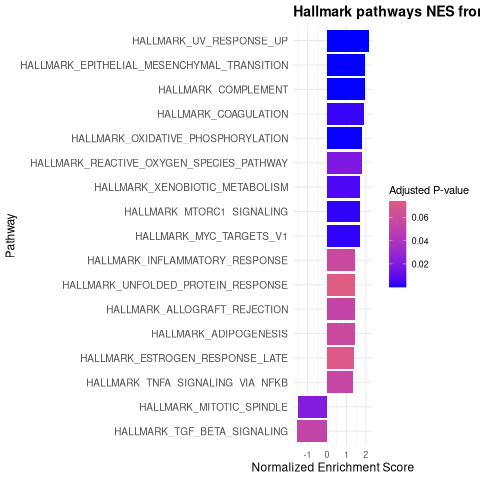

In [40]:
%%R

# Filter fgseaResSignificant to include only the main pathways from collapsedPathways
filtered_fgseaResSignificant <- fgseaResSignificant %>%
  filter(pathway %in% collapsedPathways$mainPathways)

# Create the ggplot with a color scale for padj
ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

In [41]:
%%R

# Remove "HALLMARK_" prefix from the 'pathway' column
filtered_fgseaResSignificant$pathway <- gsub("^HALLMARK_", "", filtered_fgseaResSignificant$pathway)

# View the updated heatmap_df
head(filtered_fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                padj   NES  size
  <chr>                                 <dbl> <dbl> <int>
1 UV_RESPONSE_UP                    0.0000540  2.16    71
2 EPITHELIAL_MESENCHYMAL_TRANSITION 0.000168   1.95    80
3 COMPLEMENT                        0.000168   1.93   100
4 OXIDATIVE_PHOSPHORYLATION         0.000307   1.81   133
5 MTORC1_SIGNALING                  0.00251    1.70   109
6 MYC_TARGETS_V1                    0.00251    1.68   112


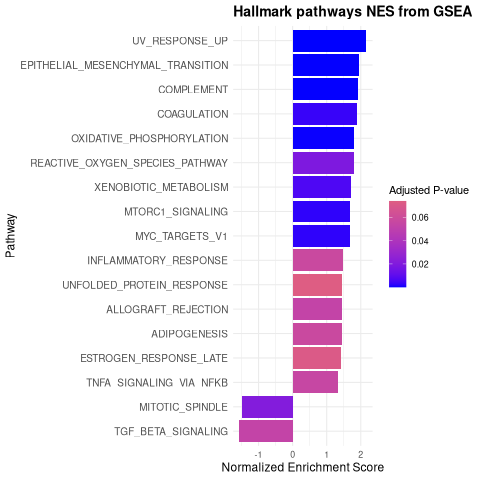

In [42]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/MOL_AL_hallmark_pathways_NES_GSEA.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

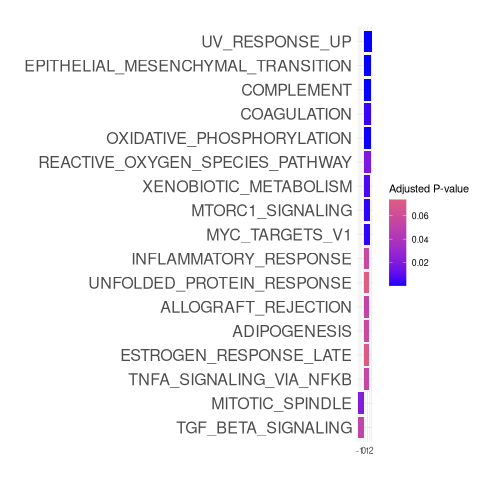

In [43]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "", y = "",
       title = "") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 16),
    axis.title = element_text(size = 16),
    plot.title = element_text(size = 16, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/MOL_NAWM_hallmark_pathways_NES_GSEA2.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

In [44]:
%%R

fgsea_MOL2_significant <- as.data.frame(fgsea_MOL2_significant)

In [45]:
%%R
library(data.table)
fwrite(fgsea_MOL2_significant, file = "./files/filtered_fgseaResSignificant_NAWM_all_glmm_zscore_MG_noPVM.csv")

In [ ]:
%%R
unique(fgsea_MOL2_significant$pathway)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_IL6_JAK_STAT3_SIGNALING"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL2_significant[fgsea_MOL2_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R
# Filter genes_down_sorted for genes in leading_edge_genes
matching_genes <- genes_up_sorted[genes_up_sorted$gene %in% leading_edge_genes, ]

# Print the filtered data frame
print(matching_genes)

# Optionally, count the number of matching genes
num_matching_genes <- nrow(matching_genes)
cat("Number of matching genes found in genes_down_sorted:", num_matching_genes, "\n")

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_INTERFERON_ALPHA_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL2_significant[fgsea_MOL2_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R
# Filter genes_down_sorted for genes in leading_edge_genes
matching_genes <- genes_up_sorted[genes_up_sorted$gene %in% leading_edge_genes, ]

# Print the filtered data frame
print(matching_genes)

# Optionally, count the number of matching genes
num_matching_genes <- nrow(matching_genes)
cat("Number of matching genes found in genes_down_sorted:", num_matching_genes, "\n")

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_INTERFERON_GAMMA_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL2_significant[fgsea_MOL2_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R
# Filter genes_down_sorted for genes in leading_edge_genes
matching_genes <- genes_up_sorted[genes_up_sorted$gene %in% leading_edge_genes, ]

# Print the filtered data frame
print(matching_genes)

# Optionally, count the number of matching genes
num_matching_genes <- nrow(matching_genes)
cat("Number of matching genes found in genes_down_sorted:", num_matching_genes, "\n")

# AL_MOL

In [46]:
%%R

# Replace the file path with the actual path if the file is not in the current directory
df <- read.csv("./files/GLMM_full_results_with_quality_ALvWM_MG_noPVM_cleaned.csv")
head(df)  # Display the first few rows of the data frame to confirm it's loaded correctly

        gene   logFC_WM        se       pvalue convergence pdHess    logLik
1 AC008691.1  3.0656211 0.4145585 1.415082e-13           0   TRUE -210.4721
2      STRBP  0.7053662 0.1109145 2.023457e-10           0   TRUE -180.8171
3      TSHZ3 -2.6148332 0.4132612 2.494663e-10           0   TRUE -110.8953
4      ABCC4  1.2055680 0.1925708 3.840221e-10           0   TRUE -223.6390
5       MAFB -1.7986934 0.2900850 5.625767e-10           0   TRUE -169.0943
6       AKT3  0.6798846 0.1112351 9.830495e-10           0   TRUE -213.8245
       AIC error          FDR status
1 438.9442    NA 1.773380e-09     OK
2 379.6342    NA 7.815780e-07     OK
3 239.7906    NA 7.815780e-07     OK
4 465.2780    NA 9.625129e-07     OK
5 356.1885    NA 1.175035e-06     OK
6 445.6490    NA 1.701168e-06     OK


In [47]:
%%R

df <- df %>%
  mutate(logFC_rev = logFC_WM * -1)

In [48]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_up <- df[df$FDR < 0.05 & df$logFC_rev > 0.585, ]
num_genes_up <- nrow(genes_up)

# Print the number of significant genes
print(num_genes_up)

genes_up_sorted <- genes_up[order(genes_up$logFC_rev, decreasing = TRUE), ]

# View the head of the significant genes data frame
head(genes_up_sorted)

[1] 316
      gene  logFC_WM       se       pvalue convergence pdHess     logLik
641  CSMD1 -8.648314 2.754630 1.692045e-03           0   TRUE  -82.74872
521 GABRB2 -5.102557 1.554200 1.026809e-03           0   TRUE  -85.64519
423  SHOX2 -4.884892 1.406873 5.162817e-04           0   TRUE  -81.23868
234   GFAP -4.336779 1.103333 8.472779e-05           0   TRUE -109.05206
68   CD163 -4.332944 0.891304 1.165858e-06           0   TRUE -149.44717
221  TRHDE -4.323725 1.086534 6.909702e-05           0   TRUE -121.03922
         AIC error          FDR status logFC_rev
641 183.4974    NA 0.0298657787     OK  8.648314
521 189.2904    NA 0.0224180574     OK  5.102557
423 180.4774    NA 0.0138248757     OK  4.884892
234 236.1041    NA 0.0041803489     OK  4.336779
68  316.8943    NA 0.0002057821     OK  4.332944
221 260.0784    NA 0.0036231123     OK  4.323725


In [49]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_down <- df[df$FDR < 0.05 & df$logFC_rev < -0.585, ]
num_genes_down <- nrow(genes_down)

# Print the number of significant genes
print(num_genes_down)

genes_down_sorted <- genes_down[order(genes_down$logFC_rev, decreasing = FALSE), ]

# View the head of the significant genes data frame
head(genes_down_sorted)

[1] 262
          gene logFC_WM        se       pvalue convergence pdHess     logLik
861 AJ009632.2 4.531003 1.5583285 0.0036420875           0   TRUE  -76.15001
650     PPFIA4 3.764061 1.2014914 0.0017313323           0   TRUE  -64.77943
401    CYP26C1 3.673351 1.0471761 0.0004517204           0   TRUE  -60.79922
443 AL139351.2 3.599557 1.0512219 0.0006166928           0   TRUE  -84.39642
886      HCG22 3.354083 1.1617307 0.0038875738           0   TRUE -121.04982
199  LINC00996 3.093085 0.7578426 0.0000447585           0   TRUE  -83.33799
         AIC error         FDR status logFC_rev
861 170.3000    NA 0.047643675     OK -4.531003
650 147.5589    NA 0.030093005     OK -3.764061
401 139.5984    NA 0.012721259     OK -3.673351
443 186.7928    NA 0.015804488     OK -3.599557
886 260.0996    NA 0.049423244     OK -3.354083
199 184.6760    NA 0.002638414     OK -3.093085


In [50]:
%%R

dim(df)

[1] 10675    12


In [51]:
%%R

my_genes <- df$gene
head(my_genes)

[1] "AC008691.1" "STRBP"      "TSHZ3"      "ABCC4"      "MAFB"      
[6] "AKT3"      


In [52]:
%%R
# Check column names in the dataframe
colnames(df)

 [1] "gene"        "logFC_WM"    "se"          "pvalue"      "convergence"
 [6] "pdHess"      "logLik"      "AIC"         "error"       "FDR"        
[11] "status"      "logFC_rev"  


In [53]:
%%R

df[df$pvalue == 0, ]

      gene logFC_WM se pvalue convergence pdHess logLik AIC error FDR status
NA    <NA>       NA NA     NA          NA     NA     NA  NA    NA  NA   <NA>
NA.1  <NA>       NA NA     NA          NA     NA     NA  NA    NA  NA   <NA>
NA.2  <NA>       NA NA     NA          NA     NA     NA  NA    NA  NA   <NA>
NA.3  <NA>       NA NA     NA          NA     NA     NA  NA    NA  NA   <NA>
NA.4  <NA>       NA NA     NA          NA     NA     NA  NA    NA  NA   <NA>
NA.5  <NA>       NA NA     NA          NA     NA     NA  NA    NA  NA   <NA>
NA.6  <NA>       NA NA     NA          NA     NA     NA  NA    NA  NA   <NA>
NA.7  <NA>       NA NA     NA          NA     NA     NA  NA    NA  NA   <NA>
NA.8  <NA>       NA NA     NA          NA     NA     NA  NA    NA  NA   <NA>
NA.9  <NA>       NA NA     NA          NA     NA     NA  NA    NA  NA   <NA>
NA.10 <NA>       NA NA     NA          NA     NA     NA  NA    NA  NA   <NA>
NA.11 <NA>       NA NA     NA          NA     NA     NA  NA    NA  NA   <NA>

In [54]:
%%R
df <- df[!is.na(df$pvalue) & !is.na(df$logFC_rev), ]
dim(df)

[1] 10652    12


In [55]:
%%R

# Filter the dataset for significant genes
filtered_df <- df[abs(df$logFC_rev) >= 0.585 & df$FDR < 0.05, ]

# Compute ranking score: sign(logFC) * -log10(P.Value)
filtered_df$ranking_score <- sign(filtered_df$logFC_rev) * -log10(filtered_df$FDR)

# Assign names to the rankings
rankings <- filtered_df$ranking_score
names(rankings) <- filtered_df$gene

# Sort the rankings in descending order
rankings <- sort(rankings, decreasing = TRUE)

In [56]:
%%R

# Ensure the length of the gene column matches the length of rankings
length(df$gene) == length(rankings)

[1] FALSE


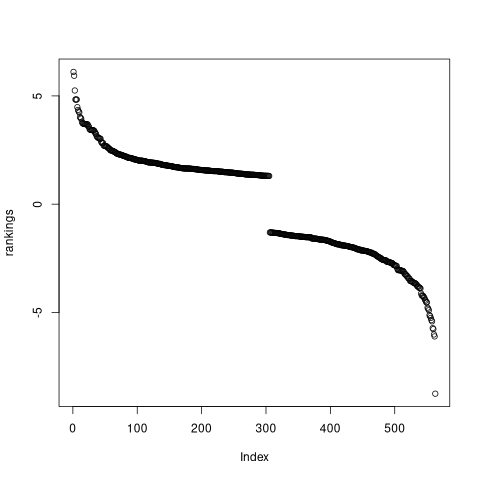

In [57]:
%%R

plot(rankings)

In [58]:
%%R

# Start with the original dataframe
clean_df <- df

# Replace p-values of exactly 0 with a very small number
# Using machine epsilon * 10 to avoid numerical issues
min_pvalue <- .Machine$double.eps * 10
clean_df$pvalue[clean_df$pvalue == 0] <- min_pvalue

# Calculate Z-score from unadjusted p-value and log fold change sign
# Z-score = qnorm(p/2, lower.tail=FALSE) * sign(logFC)
# Using p/2 for two-tailed test conversion
clean_df$z_score <- qnorm(clean_df$pvalue/2, lower.tail = FALSE) * sign(clean_df$logFC_rev)

# Create rankings for FGSEA
rankings <- clean_df$z_score
names(rankings) <- clean_df$gene

# Remove any remaining NA or infinite values that might have been created
rankings <- rankings[is.finite(rankings)]

# Sort the rankings in descending order
rankings <- sort(rankings, decreasing = TRUE)

# Optional: Check the distribution of your rankings
print(paste("Number of genes in ranking:", length(rankings)))
print(paste("Range of Z-scores:", round(min(rankings), 2), "to", round(max(rankings), 2)))
print(head(rankings, 10))  # Show top 10 genes

[1] "Number of genes in ranking: 10652"
[1] "Range of Z-scores: -7.39 to 6.33"
    TSHZ3      MAFB      DPYD LINC01146    STEAP3     SEPT9      CTSZ      BST2 
 6.327313  6.200574  5.786044  5.583045  5.566624  5.560809  5.368261  5.292307 
     BRI3     STAB1 
 5.253654  5.244426 


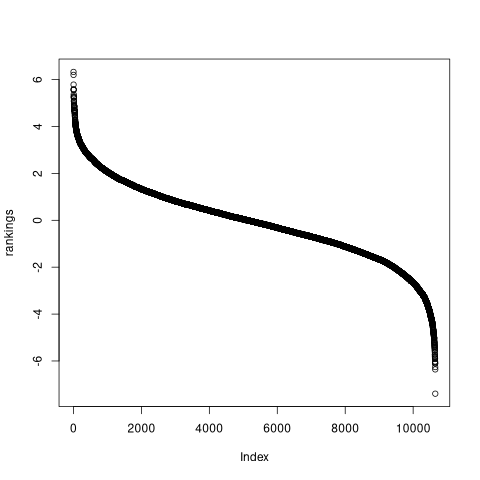

In [59]:
%%R

plot(rankings)

In [60]:
%%R

max(rankings)

[1] 6.327313


In [61]:
%%R

min(rankings)

[1] -7.394906


# Figure out how to set up gene lists

In [62]:
%%R
fgsea_res <- fgsea(pathways = pathwaysH, 
                  stats    = rankings,
                  scoreType = 'std',
                  minSize  = 15,
                  maxSize  = 500)

In [63]:
%%R
fgsea_res

                                       pathway         pval         padj
                                        <char>        <num>        <num>
 1:                      HALLMARK_ADIPOGENESIS 4.026604e-04 0.0098651795
 2:               HALLMARK_ALLOGRAFT_REJECTION 4.472823e-02 0.1311888664
 3:                 HALLMARK_ANDROGEN_RESPONSE 2.513181e-01 0.3848308436
 4:                      HALLMARK_ANGIOGENESIS 5.144766e-01 0.5862640493
 5:                   HALLMARK_APICAL_JUNCTION 3.613861e-01 0.5059285905
 6:                    HALLMARK_APICAL_SURFACE 2.306306e-01 0.3848308436
 7:                         HALLMARK_APOPTOSIS 1.356966e-03 0.0221637822
 8:              HALLMARK_BILE_ACID_METABOLISM 1.034483e-01 0.2304075235
 9:           HALLMARK_CHOLESTEROL_HOMEOSTASIS 5.108696e-01 0.5862640493
10:                       HALLMARK_COAGULATION 8.295964e-02 0.1935724963
11:                        HALLMARK_COMPLEMENT 5.845224e-03 0.0477359938
12:                        HALLMARK_DNA_REPAIR 5.97

In [64]:
%%R

dim(fgsea_res)

[1] 49  8


In [65]:
%%R
library(data.table)

#fwrite(fgsea_res, file = "./files/fgsea_ALvWM_GvC_all.csv")

In [66]:
%%R

# Filter for significant results with padj < 0.05
fgsea_MOL2_significant <- fgsea_res %>% filter(padj < 0.1)
dim(fgsea_MOL2_significant)

[1] 10  8


In [67]:
%%R

head(fgsea_MOL2_significant)

                     pathway         pval       padj   log2err        ES
                      <char>        <num>      <num>     <num>     <num>
1:     HALLMARK_ADIPOGENESIS 0.0004026604 0.00986518 0.4984931 0.3527271
2:        HALLMARK_APOPTOSIS 0.0013569663 0.02216378 0.4550599 0.3632442
3:       HALLMARK_COMPLEMENT 0.0058452237 0.04773599 0.4070179 0.3142381
4: HALLMARK_MTORC1_SIGNALING 0.0073046800 0.05113276 0.4070179 0.2974898
5:   HALLMARK_MYC_TARGETS_V1 0.0020792191 0.02547043 0.4317077 0.3199440
6:      HALLMARK_P53_PATHWAY 0.0115441139 0.05656616 0.3807304 0.2950520
        NES  size                               leadingEdge
      <num> <int>                                    <list>
1: 1.662689   127    IDH1,LPL,CD151,APOE,SPARCL1,SORBS1,...
2: 1.660626   108   DPYD,HMOX1,BCAP31,CD44,PMAIP1,CASP7,...
3: 1.494435   136      APOC1,SIRT6,CPM,CASP5,CASP7,PFN1,...
4: 1.434661   151 IDH1,SERPINH1,HSPD1,NUPR1,STIP1,HSPA4,...
5: 1.541179   155      HSPD1,CCT3,NHP2,CCT5,PCBP1,PRPS2,

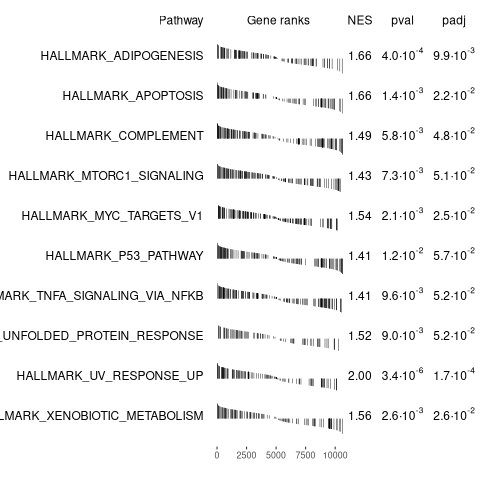

In [68]:
%%R

plotGseaTable(pathwaysH[fgsea_MOL2_significant$pathway], 
              rankings, 
              fgsea_MOL2_significant, 
              gseaParam = 0.5)

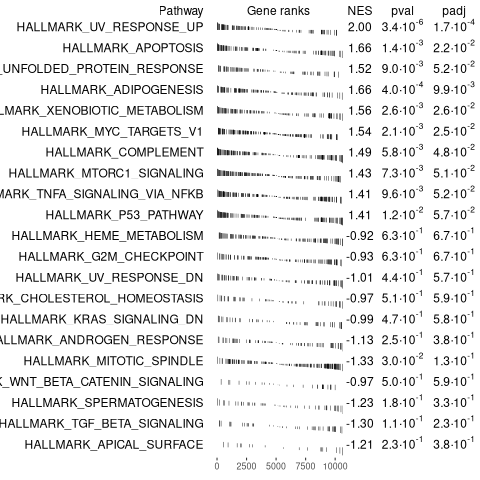

In [69]:
%%R

topUp <- fgsea_res %>% 
    filter(ES > 0) %>% 
    top_n(10, wt=-padj)
topDown <- fgsea_res %>% 
    filter(ES < 0) %>% 
    top_n(10, wt=-padj)
topPathways <- bind_rows(topUp, topDown) %>% 
    arrange(-ES)
plotGseaTable(pathwaysH[topPathways$pathway], 
              rankings, 
              fgsea_res, 
              gseaParam = 0.5)

In [70]:
%%R

collapsedPathways <- collapsePathways(fgsea_MOL2_significant[order(pval)][padj < 0.1], 
                                      pathwaysH, rankings)

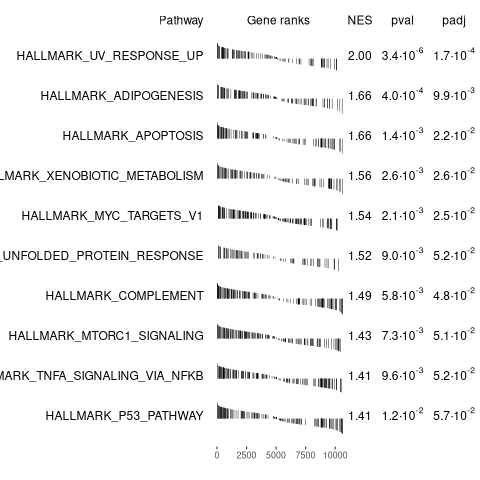

In [71]:
%%R

mainPathways <- fgsea_MOL2_significant[pathway %in% collapsedPathways$mainPathways][
                         order(-NES), pathway]
plotGseaTable(pathwaysH[mainPathways], rankings, fgsea_MOL2_significant, 
              gseaParam = 0.5)

In [72]:
%%R

fgseaResTidy <- fgsea_res %>%
  as_tibble() %>%
  arrange(desc(NES))

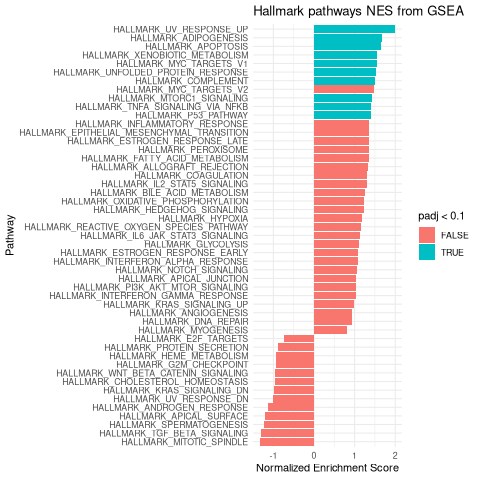

In [73]:
%%R

ggplot(fgseaResTidy, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill=padj<0.1)) +
  coord_flip() +
  labs(x="Pathway", y="Normalized Enrichment Score",
       title="Hallmark pathways NES from GSEA") + 
  theme_minimal()


#https://stephenturner.github.io/deseq-to-fgsea/#using_the_fgsea_package

In [74]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.1, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                            padj   NES  size
  <chr>                             <dbl> <dbl> <int>
1 HALLMARK_UV_RESPONSE_UP        0.000168  2.00   103
2 HALLMARK_ADIPOGENESIS          0.00987   1.66   127
3 HALLMARK_APOPTOSIS             0.0222    1.66   108
4 HALLMARK_MYC_TARGETS_V1        0.0255    1.54   155
5 HALLMARK_XENOBIOTIC_METABOLISM 0.0257    1.56   105
6 HALLMARK_COMPLEMENT            0.0477    1.49   136


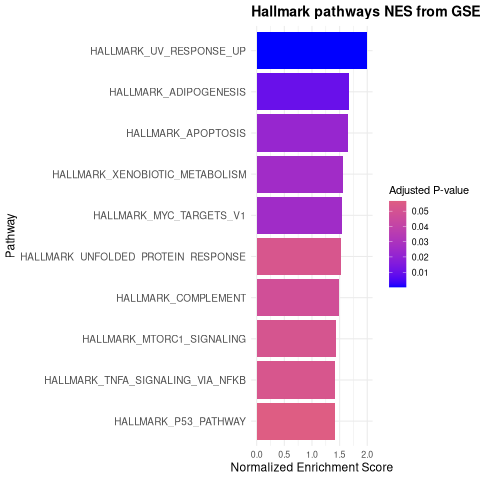

In [75]:
%%R

# Create the ggplot with a color scale for padj
ggplot(fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

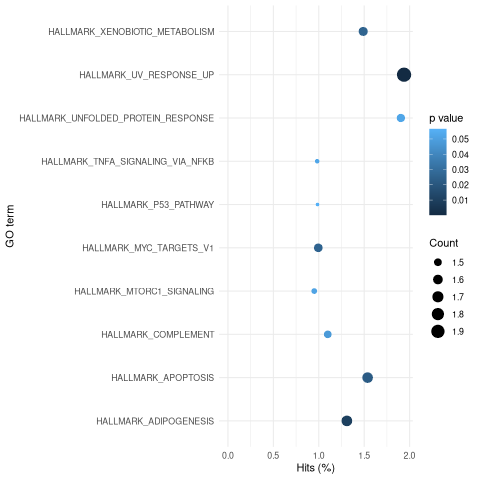

In [76]:
%%R

# Calculate hits percentage (if 'numDEInCat' and 'numInCat' equivalent are 'NES' and 'size')
fgseaResSignificant <- fgseaResSignificant %>%
  mutate(hitsPerc = NES * 100 / size)

# Ensure the columns 'padj' and 'NES' are present for the plot
fgseaResSignificant <- fgseaResSignificant %>%
  rename(term = pathway, over_represented_pvalue = padj, numDEInCat = NES)

# Create the plot
ggplot(fgseaResSignificant, aes(x = hitsPerc, y = term, colour = over_represented_pvalue, size = numDEInCat)) +
  geom_point() +
  expand_limits(x = 0) +
  labs(x = "Hits (%)", y = "GO term", colour = "p value", size = "Count") +
  theme_minimal()

#https://bioinformatics-core-shared-training.github.io/cruk-summer-school-2018/RNASeq2018/html/06_Gene_set_testing.nb.html

In [77]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.1, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                            padj   NES  size
  <chr>                             <dbl> <dbl> <int>
1 HALLMARK_UV_RESPONSE_UP        0.000168  2.00   103
2 HALLMARK_ADIPOGENESIS          0.00987   1.66   127
3 HALLMARK_APOPTOSIS             0.0222    1.66   108
4 HALLMARK_MYC_TARGETS_V1        0.0255    1.54   155
5 HALLMARK_XENOBIOTIC_METABOLISM 0.0257    1.56   105
6 HALLMARK_COMPLEMENT            0.0477    1.49   136


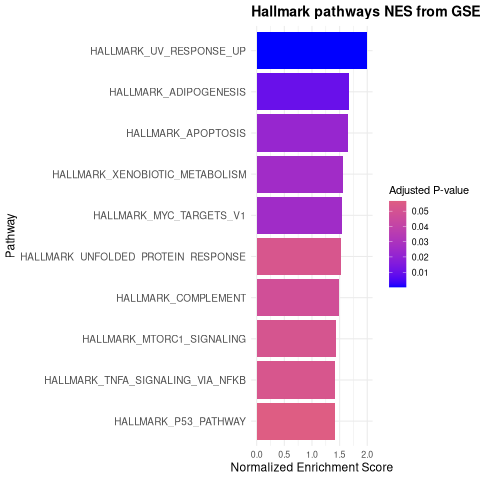

In [78]:
%%R

# Filter fgseaResSignificant to include only the main pathways from collapsedPathways
filtered_fgseaResSignificant <- fgseaResSignificant %>%
  filter(pathway %in% collapsedPathways$mainPathways)

# Create the ggplot with a color scale for padj
ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

In [79]:
%%R

# Remove "HALLMARK_" prefix from the 'pathway' column
filtered_fgseaResSignificant$pathway <- gsub("^HALLMARK_", "", filtered_fgseaResSignificant$pathway)

# View the updated heatmap_df
head(filtered_fgseaResSignificant)

# A tibble: 6 × 4
  pathway                   padj   NES  size
  <chr>                    <dbl> <dbl> <int>
1 UV_RESPONSE_UP        0.000168  2.00   103
2 ADIPOGENESIS          0.00987   1.66   127
3 APOPTOSIS             0.0222    1.66   108
4 MYC_TARGETS_V1        0.0255    1.54   155
5 XENOBIOTIC_METABOLISM 0.0257    1.56   105
6 COMPLEMENT            0.0477    1.49   136


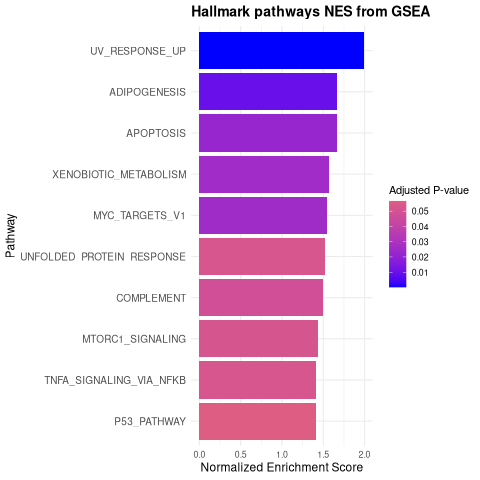

In [80]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/MOL_AL_hallmark_pathways_NES_GSEA.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

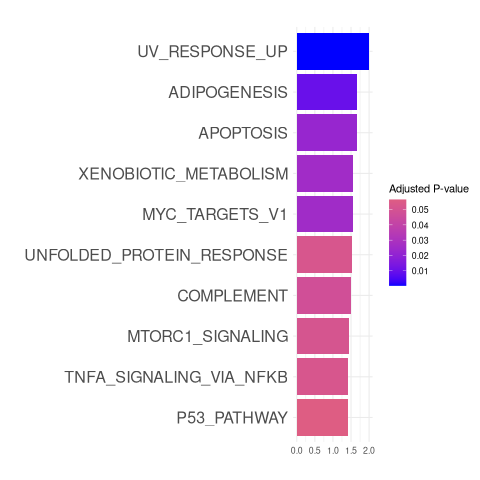

In [81]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "", y = "",
       title = "") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 16),
    axis.title = element_text(size = 16),
    plot.title = element_text(size = 16, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/MOL_AL_hallmark_pathways_NES_GSEA2.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

In [82]:
%%R

fgsea_MOL2_significant <- as.data.frame(fgsea_MOL2_significant)

In [83]:
%%R
library(data.table)
fwrite(fgsea_MOL2_significant, file = "./files/filtered_fgseaResSignificant_AL_all_glmm_zscore_MG_noPVM.csv")

In [ ]:
%%R
unique(fgsea_MOL2_significant$pathway)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_INTERFERON_GAMMA_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL2_significant[fgsea_MOL2_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_CHOLESTEROL_HOMEOSTASIS"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL2_significant[fgsea_MOL2_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R
# Filter genes_down_sorted for genes in leading_edge_genes
matching_genes <- genes_up_sorted[genes_up_sorted$gene %in% leading_edge_genes, ]

# Print the filtered data frame
print(matching_genes)

# Optionally, count the number of matching genes
num_matching_genes <- nrow(matching_genes)
cat("Number of matching genes found in genes_down_sorted:", num_matching_genes, "\n")

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_INTERFERON_ALPHA_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL2_significant[fgsea_MOL2_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R
# Filter genes_down_sorted for genes in leading_edge_genes
matching_genes <- genes_up_sorted[genes_up_sorted$gene %in% leading_edge_genes, ]

# Print the filtered data frame
print(matching_genes)

# Optionally, count the number of matching genes
num_matching_genes <- nrow(matching_genes)
cat("Number of matching genes found in genes_down_sorted:", num_matching_genes, "\n")

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_INTERFERON_GAMMA_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL2_significant[fgsea_MOL2_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R
# Filter genes_down_sorted for genes in leading_edge_genes
matching_genes <- genes_up_sorted[genes_up_sorted$gene %in% leading_edge_genes, ]

# Print the filtered data frame
print(matching_genes)

# Optionally, count the number of matching genes
num_matching_genes <- nrow(matching_genes)
cat("Number of matching genes found in genes_down_sorted:", num_matching_genes, "\n")

# CAL

In [84]:
%%R

# Replace the file path with the actual path if the file is not in the current directory
df <- read.csv("./files/GLMM_full_results_with_quality_CALvWM_MG_noPVM_cleaned.csv")
head(df)  # Display the first few rows of the data frame to confirm it's loaded correctly

        gene   logFC_WM         se       pvalue convergence pdHess     logLik
1     STEAP3 -1.0090155 0.11467347 1.380019e-18           0   TRUE  -93.46895
2 AC008691.1  3.6005564 0.42763278 3.773235e-17           0   TRUE -175.07909
3     MTMR10  0.5979553 0.08031434 9.680735e-14           0   TRUE -118.61966
4     CLEC5A -2.8430393 0.40400500 1.962270e-12           0   TRUE -121.04686
5      TSHZ3 -2.6720053 0.38505863 3.942796e-12           0   TRUE  -97.89476
6      ABCC4  1.4045931 0.20856546 1.644455e-11           0   TRUE -196.97301
       AIC error          FDR status
1 204.9379    NA 1.646915e-14     OK
2 368.1582    NA 2.251489e-13     OK
3 255.2393    NA 2.888247e-10     OK
4 260.0937    NA 3.902956e-09     OK
5 213.7895    NA 6.721904e-09     OK
6 411.9460    NA 1.980498e-08     OK


In [85]:
%%R

df <- df %>%
  mutate(logFC_rev = logFC_WM * -1)

In [86]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_up <- df[df$FDR < 0.05 & df$logFC_rev > 0.585, ]
num_genes_up <- nrow(genes_up)

# Print the number of significant genes
print(num_genes_up)

genes_up_sorted <- genes_up[order(genes_up$logFC_rev, decreasing = TRUE), ]

# View the head of the significant genes data frame
head(genes_up_sorted)

[1] 383
       gene  logFC_WM        se       pvalue convergence pdHess     logLik
41     GFAP -6.121539 1.1352177 6.952586e-08           0   TRUE  -99.48181
154  HSPA4L -5.503231 1.2474711 1.026522e-05           0   TRUE  -97.97398
95    PHGDH -5.175201 1.1015578 2.626250e-06           0   TRUE  -44.73391
97    TRHDE -4.644005 0.9905687 2.755897e-06           0   TRUE -111.26201
229    DOK2 -4.214121 1.0210710 3.672742e-05           0   TRUE  -69.85623
28  FAM135B -4.207072 0.7482511 1.881687e-08           0   TRUE -101.87898
         AIC error          FDR status logFC_rev
41  216.9636    NA 1.843826e-05     OK  6.121539
154 213.9480    NA 7.248828e-04     OK  5.503231
95  107.4678    NA 2.956761e-04     OK  5.175201
97  240.5240    NA 3.017328e-04     OK  4.644005
229 157.7125    NA 1.760261e-03     OK  4.214121
28  221.7580    NA 7.243886e-06     OK  4.207072


In [87]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_down <- df[df$FDR < 0.05 & df$logFC_rev < -0.585, ]
num_genes_down <- nrow(genes_down)

# Print the number of significant genes
print(num_genes_down)

genes_down_sorted <- genes_down[order(genes_down$logFC_rev, decreasing = FALSE), ]

# View the head of the significant genes data frame
head(genes_down_sorted)

[1] 589
          gene logFC_WM        se       pvalue convergence pdHess     logLik
994       VWC2 5.920158 2.0093522 3.215984e-03           0   TRUE  -87.52292
215     SEMA7A 4.389004 1.0493479 2.881928e-05           0   TRUE  -77.08184
694 AL139351.2 4.152416 1.2706987 1.083789e-03           0   TRUE  -66.89726
99      IGSF10 3.842993 0.8211956 2.872198e-06           0   TRUE  -94.48639
845      PTPRB 3.768567 1.2298056 2.181364e-03           0   TRUE  -92.06842
686      HCG22 3.683021 1.1255008 1.066614e-03           0   TRUE -107.26253
         AIC error          FDR status logFC_rev
994 193.0458    NA 0.0349222489     OK -5.920158
215 172.1637    NA 0.0014697831     OK -4.389004
694 151.7945    NA 0.0170379568     OK -4.152416
99  206.9728    NA 0.0003116073     OK -3.842993
845 202.1368    NA 0.0278558584     OK -3.768567
686 232.5251    NA 0.0168819329     OK -3.683021


In [88]:
%%R

dim(df)

[1] 10749    12


In [89]:
%%R

my_genes <- df$gene
head(my_genes)

[1] "STEAP3"     "AC008691.1" "MTMR10"     "CLEC5A"     "TSHZ3"     
[6] "ABCC4"     


In [90]:
%%R
# Check column names in the dataframe
colnames(df)

 [1] "gene"        "logFC_WM"    "se"          "pvalue"      "convergence"
 [6] "pdHess"      "logLik"      "AIC"         "error"       "FDR"        
[11] "status"      "logFC_rev"  


In [91]:
%%R

df <- df[!is.na(df$pvalue) & !is.na(df$logFC_rev), ]
dim(df)

[1] 10727    12


In [92]:
%%R

# Start with the original dataframe
clean_df <- df

# Replace p-values of exactly 0 with a very small number
# Using machine epsilon * 10 to avoid numerical issues
min_pvalue <- .Machine$double.eps * 10
clean_df$pvalue[clean_df$pvalue == 0] <- min_pvalue

# Calculate Z-score from unadjusted p-value and log fold change sign
# Z-score = qnorm(p/2, lower.tail=FALSE) * sign(logFC)
# Using p/2 for two-tailed test conversion
clean_df$z_score <- qnorm(clean_df$pvalue/2, lower.tail = FALSE) * sign(clean_df$logFC_rev)

# Create rankings for FGSEA
rankings <- clean_df$z_score
names(rankings) <- clean_df$gene

# Remove any remaining NA or infinite values that might have been created
rankings <- rankings[is.finite(rankings)]

# Sort the rankings in descending order
rankings <- sort(rankings, decreasing = TRUE)

# Optional: Check the distribution of your rankings
print(paste("Number of genes in ranking:", length(rankings)))
print(paste("Range of Z-scores:", round(min(rankings), 2), "to", round(max(rankings), 2)))
print(head(rankings, 10))  # Show top 10 genes

[1] "Number of genes in ranking: 10727"
[1] "Range of Z-scores: -8.42 to 8.8"
  STEAP3   CLEC5A    TSHZ3    STAB1 SERPINH1 ARHGAP10   ADGRG6   DNAJA4 
8.799032 7.037139 6.939217 6.406785 6.075157 5.919230 5.806241 5.755200 
 FAM135B   PLXNC1 
5.622541 5.613981 


In [93]:
%%R

# Ensure the length of the gene column matches the length of rankings
length(df$gene) == length(rankings)

[1] TRUE


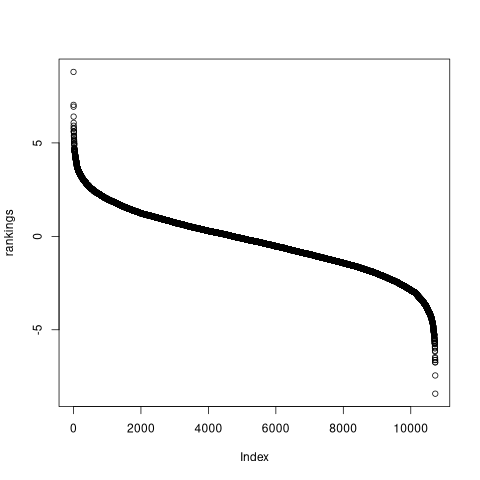

In [94]:
%%R

plot(rankings)

In [95]:
%%R

max(rankings)

[1] 8.799032


In [96]:
%%R

min(rankings)

[1] -8.419739


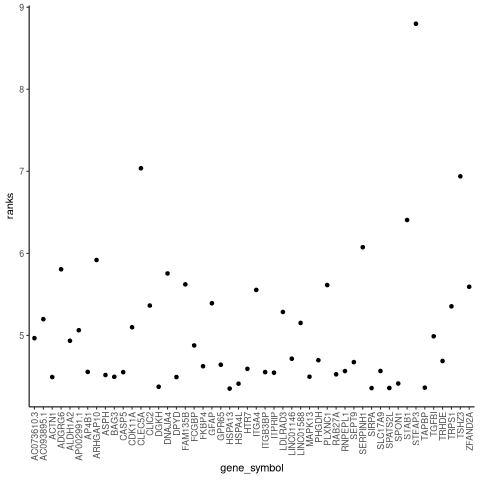

In [97]:
%%R

ggplot(data.frame(gene_symbol = names(rankings)[1:50], ranks = rankings[1:50]), aes(gene_symbol, ranks)) + 
    geom_point() +
    theme_classic() + 
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

# Figure out how to set up gene lists

In [98]:
%%R
fgsea_res <- fgsea(pathways = pathwaysH, 
                  stats    = rankings,
                  scoreType = 'std',
                  minSize  = 15,
                  maxSize  = 500)

In [99]:
%%R
fgsea_res

                                       pathway         pval         padj
                                        <char>        <num>        <num>
 1:                      HALLMARK_ADIPOGENESIS 4.682081e-01 0.6372832370
 2:               HALLMARK_ALLOGRAFT_REJECTION 6.311167e-01 0.7542614071
 3:                 HALLMARK_ANDROGEN_RESPONSE 3.180026e-01 0.5771158807
 4:                      HALLMARK_ANGIOGENESIS 4.484680e-01 0.6372832370
 5:                   HALLMARK_APICAL_JUNCTION 1.060821e-01 0.3122056117
 6:                    HALLMARK_APICAL_SURFACE 5.030581e-01 0.6513836137
 7:                         HALLMARK_APOPTOSIS 6.279726e-03 0.0704299541
 8:              HALLMARK_BILE_ACID_METABOLISM 1.493943e-01 0.3852801587
 9:           HALLMARK_CHOLESTEROL_HOMEOSTASIS 2.346369e-01 0.5226003047
10:                       HALLMARK_COAGULATION 6.061415e-01 0.7425233645
11:                        HALLMARK_COMPLEMENT 4.522059e-01 0.6372832370
12:                        HALLMARK_DNA_REPAIR 9.45

In [100]:
%%R

dim(fgsea_res)

[1] 49  8


In [101]:
%%R
library(data.table)

#fwrite(fgsea_res, file = "./files/fgsea_CALvWM_all_OL_glmm_full.csv")

In [102]:
%%R

# Filter for significant results with padj < 0.05
fgsea_MOL2_significant <- fgsea_res %>% filter(padj < 0.1)
dim(fgsea_MOL2_significant)

[1] 9 8


In [103]:
%%R

head(fgsea_MOL2_significant)

                                      pathway        pval       padj   log2err
                                       <char>       <num>      <num>     <num>
1:                         HALLMARK_APOPTOSIS 0.006279726 0.07042995 0.4070179
2: HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION 0.011841734 0.07253062 0.3807304
3:            HALLMARK_ESTROGEN_RESPONSE_LATE 0.010929949 0.07253062 0.3807304
4:                   HALLMARK_MITOTIC_SPINDLE 0.013560397 0.07382883 0.3807304
5:                    HALLMARK_MYC_TARGETS_V2 0.001372946 0.02242478 0.4550599
6:                       HALLMARK_P53_PATHWAY 0.008624076 0.07042995 0.3807304
           ES       NES  size                                  leadingEdge
        <num>     <num> <int>                                       <list>
1:  0.2919358  1.429534   107       DPYD,CDC25B,HSPB1,HMOX1,ANXA1,SOD2,...
2:  0.2989820  1.408851    85   SERPINH1,TGFBI,VIM,ITGB1,CAP2,COLGALT1,...
3:  0.2923559  1.414554   102       FKBP4,MAPK13,HSPA4L,CPE,EMP2,FAB

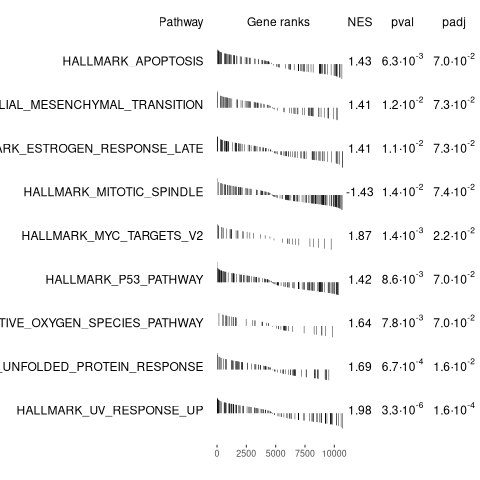

In [104]:
%%R

plotGseaTable(pathwaysH[fgsea_MOL2_significant$pathway], 
              rankings, 
              fgsea_MOL2_significant, 
              gseaParam = 0.5)

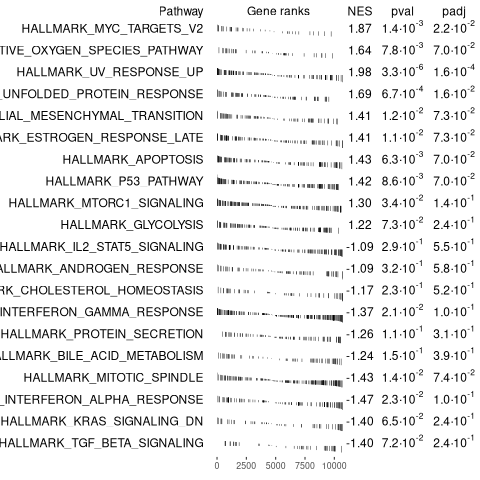

In [105]:
%%R

topUp <- fgsea_res %>% 
    filter(ES > 0) %>% 
    top_n(10, wt=-padj)
topDown <- fgsea_res %>% 
    filter(ES < 0) %>% 
    top_n(10, wt=-padj)
topPathways <- bind_rows(topUp, topDown) %>% 
    arrange(-ES)
plotGseaTable(pathwaysH[topPathways$pathway], 
              rankings, 
              fgsea_res, 
              gseaParam = 0.5)

In [106]:
%%R

collapsedPathways <- collapsePathways(fgsea_MOL2_significant[order(pval)][padj < 0.1], 
                                      pathwaysH, rankings)

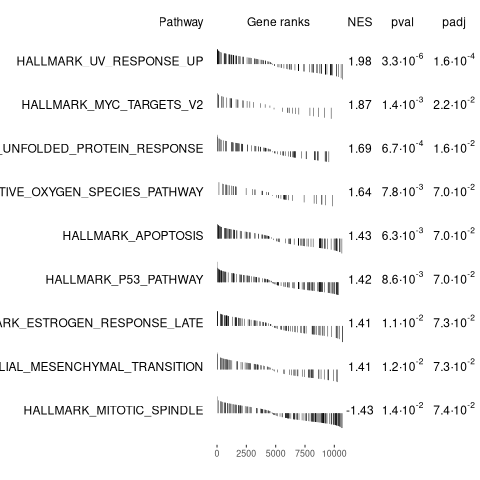

In [107]:
%%R

mainPathways <- fgsea_MOL2_significant[pathway %in% collapsedPathways$mainPathways][
                         order(-NES), pathway]
plotGseaTable(pathwaysH[mainPathways], rankings, fgsea_MOL2_significant, 
              gseaParam = 0.5)

In [108]:
%%R

fgseaResTidy <- fgsea_res %>%
  as_tibble() %>%
  arrange(desc(NES))

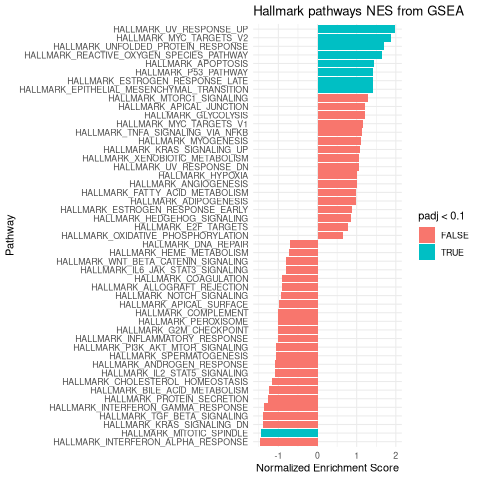

In [109]:
%%R

ggplot(fgseaResTidy, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill=padj<0.1)) +
  coord_flip() +
  labs(x="Pathway", y="Normalized Enrichment Score",
       title="Hallmark pathways NES from GSEA") + 
  theme_minimal()


#https://stephenturner.github.io/deseq-to-fgsea/#using_the_fgsea_package

In [110]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.1, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                      padj   NES  size
  <chr>                                       <dbl> <dbl> <int>
1 HALLMARK_UV_RESPONSE_UP                  0.000164  1.98   104
2 HALLMARK_UNFOLDED_PROTEIN_RESPONSE       0.0163    1.69    85
3 HALLMARK_MYC_TARGETS_V2                  0.0224    1.87    36
4 HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY 0.0704    1.64    38
5 HALLMARK_APOPTOSIS                       0.0704    1.43   107
6 HALLMARK_P53_PATHWAY                     0.0704    1.42   142


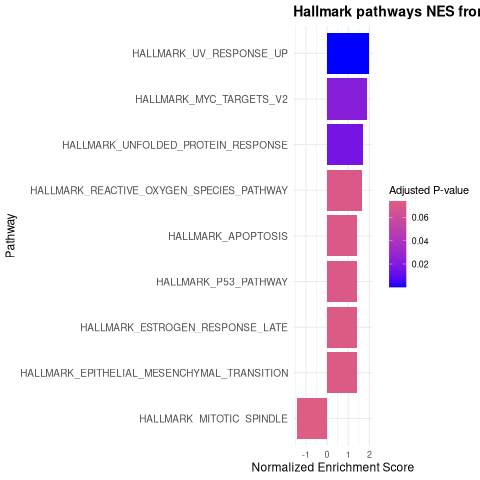

In [111]:
%%R

# Create the ggplot with a color scale for padj
ggplot(fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

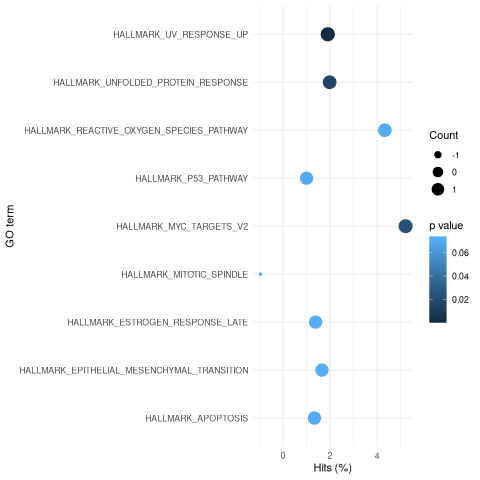

In [112]:
%%R

# Calculate hits percentage (if 'numDEInCat' and 'numInCat' equivalent are 'NES' and 'size')
fgseaResSignificant <- fgseaResSignificant %>%
  mutate(hitsPerc = NES * 100 / size)

# Ensure the columns 'padj' and 'NES' are present for the plot
fgseaResSignificant <- fgseaResSignificant %>%
  rename(term = pathway, over_represented_pvalue = padj, numDEInCat = NES)

# Create the plot
ggplot(fgseaResSignificant, aes(x = hitsPerc, y = term, colour = over_represented_pvalue, size = numDEInCat)) +
  geom_point() +
  expand_limits(x = 0) +
  labs(x = "Hits (%)", y = "GO term", colour = "p value", size = "Count") +
  theme_minimal()

#https://bioinformatics-core-shared-training.github.io/cruk-summer-school-2018/RNASeq2018/html/06_Gene_set_testing.nb.html

In [113]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.1, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                      padj   NES  size
  <chr>                                       <dbl> <dbl> <int>
1 HALLMARK_UV_RESPONSE_UP                  0.000164  1.98   104
2 HALLMARK_UNFOLDED_PROTEIN_RESPONSE       0.0163    1.69    85
3 HALLMARK_MYC_TARGETS_V2                  0.0224    1.87    36
4 HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY 0.0704    1.64    38
5 HALLMARK_APOPTOSIS                       0.0704    1.43   107
6 HALLMARK_P53_PATHWAY                     0.0704    1.42   142


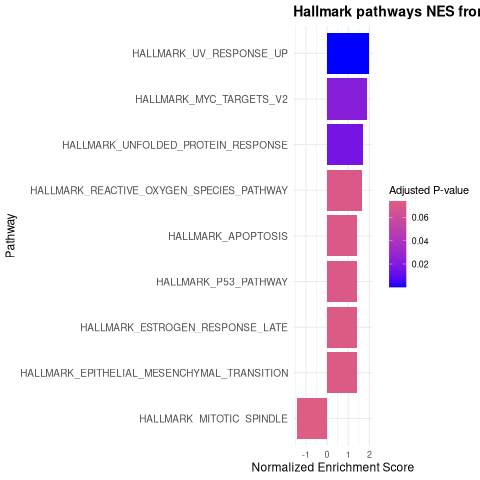

In [114]:
%%R

# Filter fgseaResSignificant to include only the main pathways from collapsedPathways
filtered_fgseaResSignificant <- fgseaResSignificant %>%
  filter(pathway %in% collapsedPathways$mainPathways)

# Create the ggplot with a color scale for padj
ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

In [115]:
%%R

# Remove "HALLMARK_" prefix from the 'pathway' column
filtered_fgseaResSignificant$pathway <- gsub("^HALLMARK_", "", filtered_fgseaResSignificant$pathway)

# View the updated heatmap_df
head(filtered_fgseaResSignificant)

# A tibble: 6 × 4
  pathway                             padj   NES  size
  <chr>                              <dbl> <dbl> <int>
1 UV_RESPONSE_UP                  0.000164  1.98   104
2 UNFOLDED_PROTEIN_RESPONSE       0.0163    1.69    85
3 MYC_TARGETS_V2                  0.0224    1.87    36
4 REACTIVE_OXYGEN_SPECIES_PATHWAY 0.0704    1.64    38
5 APOPTOSIS                       0.0704    1.43   107
6 P53_PATHWAY                     0.0704    1.42   142


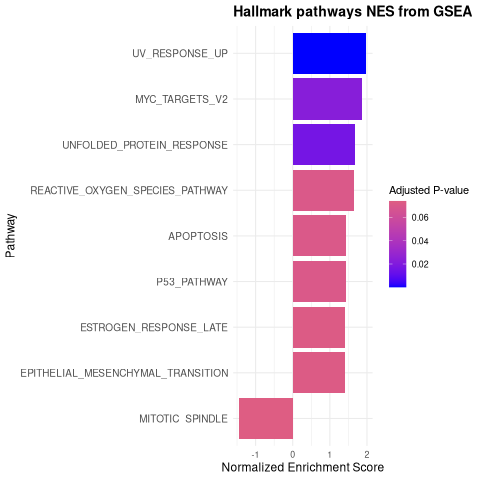

In [116]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/MOL_AL_hallmark_pathways_NES_GSEA.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

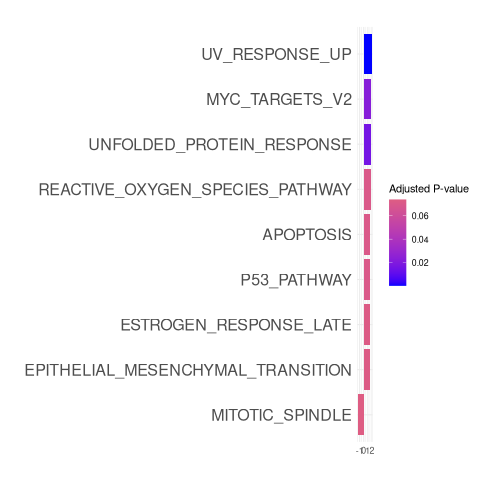

In [117]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "", y = "",
       title = "") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 16),
    axis.title = element_text(size = 16),
    plot.title = element_text(size = 16, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/MOL_CAL_hallmark_pathways_NES_GSEA2.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

In [118]:
%%R

fgsea_MOL2_significant <- as.data.frame(fgsea_MOL2_significant)

In [119]:
%%R
library(data.table)
fwrite(fgsea_MOL2_significant, file = "./files/filtered_fgseaResSignificant_CAL_all_glmm_zscore_MG_noPVM.csv")

In [120]:
%%R
unique(fgsea_MOL2_significant$pathway)

[1] "HALLMARK_APOPTOSIS"                        
[2] "HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION"
[3] "HALLMARK_ESTROGEN_RESPONSE_LATE"           
[4] "HALLMARK_MITOTIC_SPINDLE"                  
[5] "HALLMARK_MYC_TARGETS_V2"                   
[6] "HALLMARK_P53_PATHWAY"                      
[7] "HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY"  
[8] "HALLMARK_UNFOLDED_PROTEIN_RESPONSE"        
[9] "HALLMARK_UV_RESPONSE_UP"                   


In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_INTERFERON_ALPHA_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL2_significant[fgsea_MOL2_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_CHOLESTEROL_HOMEOSTASIS"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL2_significant[fgsea_MOL2_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R
# Filter genes_down_sorted for genes in leading_edge_genes
matching_genes <- genes_up_sorted[genes_up_sorted$gene %in% leading_edge_genes, ]

# Print the filtered data frame
print(matching_genes)

# Optionally, count the number of matching genes
num_matching_genes <- nrow(matching_genes)
cat("Number of matching genes found in genes_down_sorted:", num_matching_genes, "\n")

# CIL

In [121]:
%%R

# Replace the file path with the actual path if the file is not in the current directory
df <- read.csv("./files/GLMM_full_results_with_quality_CILvWM_MG_noPVM_cleaned.csv")
head(df)  # Display the first few rows of the data frame to confirm it's loaded correctly

     gene   logFC_WM         se       pvalue convergence pdHess    logLik
1 TBC1D12  0.5149479 0.05461746 4.169325e-21           0   TRUE -120.9329
2 SIGLEC9 -0.9783654 0.11833773 1.367173e-16           0   TRUE -100.5765
3  PRDM11  1.9349785 0.24756999 5.457836e-15           0   TRUE -126.8270
4  TRIM36  0.8738390 0.11330336 1.234887e-14           0   TRUE -101.3155
5    HECA  0.5609744 0.07400817 3.458240e-14           0   TRUE -104.1597
6 SIGLEC7 -1.3045622 0.17605766 1.264348e-13           0   TRUE  -70.8041
       AIC error          FDR status
1 259.8658    NA 2.416749e-17     OK
2 219.1531    NA 5.283214e-13     OK
3 271.6540    NA 1.581817e-11     OK
4 220.6310    NA 2.863210e-11     OK
5 226.3195    NA 6.681896e-11     OK
6 159.6082    NA 2.093941e-10     OK


In [122]:
%%R

df <- df %>%
  mutate(logFC_rev = logFC_WM * -1)

In [123]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_up <- df[df$FDR < 0.05 & df$logFC_rev > 0.585, ]
num_genes_up <- nrow(genes_up)

# Print the number of significant genes
print(num_genes_up)

genes_up_sorted <- genes_up[order(genes_up$logFC_rev, decreasing = TRUE), ]

# View the head of the significant genes data frame
head(genes_up_sorted)

[1] 370
     gene  logFC_WM        se       pvalue convergence pdHess     logLik
455 CSMD1 -8.829366 2.3636736 1.873857e-04           0   TRUE  -46.58651
630  AQP9 -5.547178 1.6174112 6.043271e-04           0   TRUE  -62.08406
264 S100B -5.201063 1.2276598 2.269633e-05           0   TRUE  -45.67958
788 STMN1 -5.113914 1.5996418 1.389072e-03           0   TRUE  -34.95791
21  CD163 -5.104388 0.8190685 4.606842e-10           0   TRUE -105.46912
690 TTYH1 -4.865216 1.4643739 8.925106e-04           0   TRUE  -34.37798
          AIC error          FDR status logFC_rev
455 111.17302    NA 4.091077e-03     OK  8.829366
630 142.16812    NA 9.623576e-03     OK  5.547178
264 109.35916    NA 8.588140e-04     OK  5.201063
788  87.91583    NA 1.750382e-02     OK  5.113914
21  228.93823    NA 2.305338e-07     OK  5.104388
690  86.75596    NA 1.288527e-02     OK  4.865216


In [124]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_down <- df[df$FDR < 0.05 & df$logFC_rev < -0.585, ]
num_genes_down <- nrow(genes_down)

# Print the number of significant genes
print(num_genes_down)

genes_down_sorted <- genes_down[order(genes_down$logFC_rev, decreasing = FALSE), ]

# View the head of the significant genes data frame
head(genes_down_sorted)

[1] 336
         gene logFC_WM        se       pvalue convergence pdHess    logLik
324     KCNQ5 5.658178 1.3935808 4.903648e-05           0   TRUE -75.62414
141      RGS6 4.133072 0.8521911 1.235016e-06           0   TRUE -84.46399
286 LINC01845 3.870991 0.9273031 2.986917e-05           0   TRUE -45.95931
386     TENM3 3.715571 0.9533114 9.717414e-05           0   TRUE -57.12505
429    SUCNR1 3.116172 0.8206396 1.463116e-04           0   TRUE -58.21574
441    CACNB2 2.877196 0.7634636 1.641599e-04           0   TRUE -90.73419
         AIC error          FDR status logFC_rev
324 169.2483    NA 1.507904e-03     OK -5.658178
141 186.9280    NA 8.730211e-05     OK -4.133072
286 109.9186    NA 1.046143e-03     OK -3.870991
386 132.2501    NA 2.517945e-03     OK -3.715571
429 134.4315    NA 3.399179e-03     OK -3.116172
441 199.4684    NA 3.695352e-03     OK -2.877196


In [125]:
%%R

dim(df)

[1] 9491   12


In [126]:
%%R

my_genes <- df$gene
head(my_genes)

[1] "TBC1D12" "SIGLEC9" "PRDM11"  "TRIM36"  "HECA"    "SIGLEC7"


In [127]:
%%R
# Check column names in the dataframe
colnames(df)

 [1] "gene"        "logFC_WM"    "se"          "pvalue"      "convergence"
 [6] "pdHess"      "logLik"      "AIC"         "error"       "FDR"        
[11] "status"      "logFC_rev"  


In [128]:
%%R

df <- df[!is.na(df$pvalue) & !is.na(df$logFC_rev), ]
dim(df)

[1] 9487   12


In [129]:
%%R

# Start with the original dataframe
clean_df <- df

# Replace p-values of exactly 0 with a very small number
# Using machine epsilon * 10 to avoid numerical issues
min_pvalue <- .Machine$double.eps * 10
clean_df$pvalue[clean_df$pvalue == 0] <- min_pvalue

# Calculate Z-score from unadjusted p-value and log fold change sign
# Z-score = qnorm(p/2, lower.tail=FALSE) * sign(logFC)
# Using p/2 for two-tailed test conversion
clean_df$z_score <- qnorm(clean_df$pvalue/2, lower.tail = FALSE) * sign(clean_df$logFC_rev)

# Create rankings for FGSEA
rankings <- clean_df$z_score
names(rankings) <- clean_df$gene

# Remove any remaining NA or infinite values that might have been created
rankings <- rankings[is.finite(rankings)]

# Sort the rankings in descending order
rankings <- sort(rankings, decreasing = TRUE)

# Optional: Check the distribution of your rankings
print(paste("Number of genes in ranking:", length(rankings)))
print(paste("Range of Z-scores:", round(min(rankings), 2), "to", round(max(rankings), 2)))
print(head(rankings, 10))  # Show top 10 genes

[1] "Number of genes in ranking: 9487"
[1] "Range of Z-scores: -9.43 to 8.27"
  SIGLEC9   SIGLEC7   RANBP17      DPYD     CD163      GFAP      MAFB LINC01482 
 8.267570  7.409858  6.403968  6.252779  6.231943  6.151962  6.051535  6.014123 
   FNDC3B    AGPAT2 
 5.974101  5.964839 


In [130]:
%%R

# Ensure the length of the gene column matches the length of rankings
length(df$gene) == length(rankings)

[1] TRUE


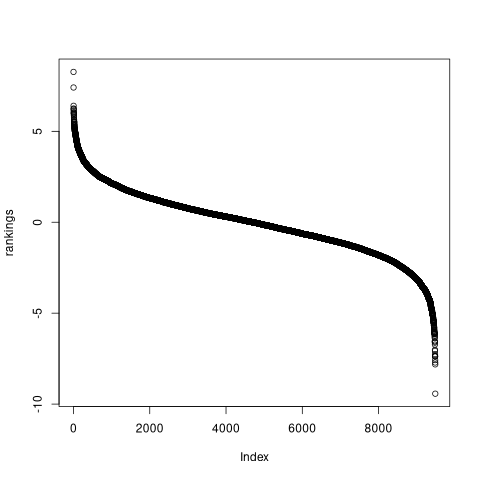

In [131]:
%%R

plot(rankings)

In [132]:
%%R

max(rankings)

[1] 8.26757


In [133]:
%%R

min(rankings)

[1] -9.428264


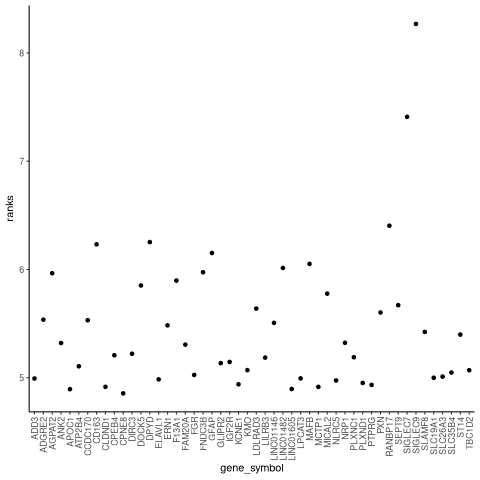

In [134]:
%%R

ggplot(data.frame(gene_symbol = names(rankings)[1:50], ranks = rankings[1:50]), aes(gene_symbol, ranks)) + 
    geom_point() +
    theme_classic() + 
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

# Figure out how to set up gene lists

In [135]:
%%R
fgsea_res <- fgsea(pathways = pathwaysH, 
                  stats    = rankings,
                  scoreType = 'std',
                  minSize  = 15,
                  maxSize  = 500)

In [136]:
%%R
fgsea_res

                                       pathway         pval       padj
                                        <char>        <num>      <num>
 1:                      HALLMARK_ADIPOGENESIS 0.0009111223 0.01194288
 2:               HALLMARK_ALLOGRAFT_REJECTION 0.2666666667 0.45057471
 3:                 HALLMARK_ANDROGEN_RESPONSE 0.8186046512 0.89785575
 4:                      HALLMARK_ANGIOGENESIS 0.1370449679 0.33576017
 5:                   HALLMARK_APICAL_JUNCTION 0.4187817259 0.64125952
 6:                    HALLMARK_APICAL_SURFACE 0.1626168224 0.36436755
 7:                         HALLMARK_APOPTOSIS 0.1350000000 0.33576017
 8:              HALLMARK_BILE_ACID_METABOLISM 0.5235602094 0.69336352
 9:           HALLMARK_CHOLESTEROL_HOMEOSTASIS 0.4582338902 0.65104895
10:                       HALLMARK_COAGULATION 0.0874704492 0.25925926
11:                        HALLMARK_COMPLEMENT 0.0324805472 0.14468607
12:                        HALLMARK_DNA_REPAIR 0.9933333333 0.99363057
13:   

In [137]:
%%R

dim(fgsea_res)

[1] 49  8


In [138]:
%%R
library(data.table)

#fwrite(fgsea_res, file = "./files/fgsea_CILvWM_GvC_all.csv")

In [139]:
%%R

# Filter for significant results with padj < 0.05
fgsea_MOL2_significant <- fgsea_res %>% filter(padj < 0.1)
dim(fgsea_MOL2_significant)

[1] 10  8


In [140]:
%%R

head(fgsea_MOL2_significant)

                                      pathway         pval       padj   log2err
                                       <char>        <num>      <num>     <num>
1:                      HALLMARK_ADIPOGENESIS 0.0009111223 0.01194288 0.4772708
2: HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION 0.0020361507 0.01662856 0.4317077
3:            HALLMARK_ESTROGEN_RESPONSE_LATE 0.0028777719 0.02014440 0.4317077
4:                        HALLMARK_GLYCOLYSIS 0.0008830580 0.01194288 0.4772708
5:                           HALLMARK_HYPOXIA 0.0070887741 0.03859444 0.4070179
6:             HALLMARK_INFLAMMATORY_RESPONSE 0.0009749290 0.01194288 0.4772708
          ES      NES  size                               leadingEdge
       <num>    <num> <int>                                    <list>
1: 0.3468485 1.604852   133 SLC19A1,LPCAT3,ABCA1,PPARG,ESYT1,RTN3,...
2: 0.3804160 1.622400    80  COLGALT1,IL15,CD44,PMP22,NOTCH2,LRP1,...
3: 0.3657018 1.596997    91     ST14,ATP2B4,ADD3,MAPK13,CD44,EMP2,...
4: 0.36187

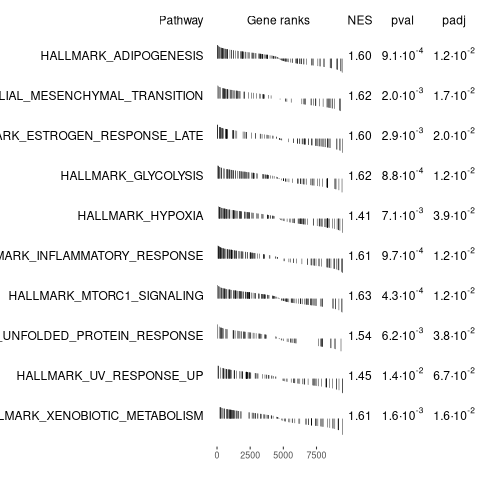

In [141]:
%%R

plotGseaTable(pathwaysH[fgsea_MOL2_significant$pathway], 
              rankings, 
              fgsea_MOL2_significant, 
              gseaParam = 0.5)

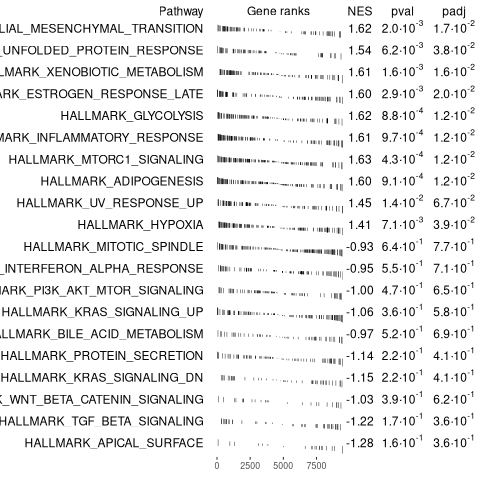

In [142]:
%%R

topUp <- fgsea_res %>% 
    filter(ES > 0) %>% 
    top_n(10, wt=-padj)
topDown <- fgsea_res %>% 
    filter(ES < 0) %>% 
    top_n(10, wt=-padj)
topPathways <- bind_rows(topUp, topDown) %>% 
    arrange(-ES)
plotGseaTable(pathwaysH[topPathways$pathway], 
              rankings, 
              fgsea_res, 
              gseaParam = 0.5)

In [143]:
%%R

collapsedPathways <- collapsePathways(fgsea_MOL2_significant[order(pval)][padj < 0.1], 
                                      pathwaysH, rankings)

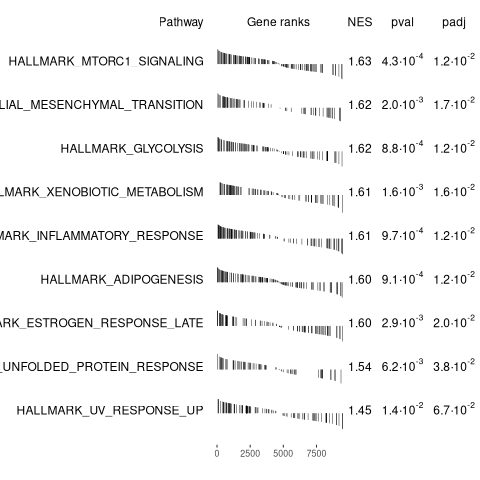

In [144]:
%%R

mainPathways <- fgsea_MOL2_significant[pathway %in% collapsedPathways$mainPathways][
                         order(-NES), pathway]
plotGseaTable(pathwaysH[mainPathways], rankings, fgsea_MOL2_significant, 
              gseaParam = 0.5)

In [145]:
%%R

fgseaResTidy <- fgsea_res %>%
  as_tibble() %>%
  arrange(desc(NES))

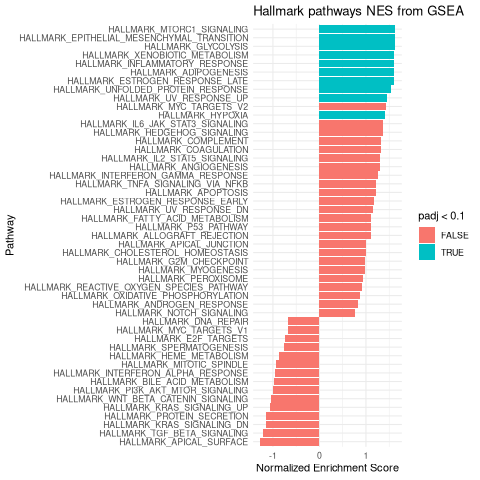

In [146]:
%%R

ggplot(fgseaResTidy, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill=padj<0.1)) +
  coord_flip() +
  labs(x="Pathway", y="Normalized Enrichment Score",
       title="Hallmark pathways NES from GSEA") + 
  theme_minimal()


#https://stephenturner.github.io/deseq-to-fgsea/#using_the_fgsea_package

In [147]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.1, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                      padj   NES  size
  <chr>                                       <dbl> <dbl> <int>
1 HALLMARK_MTORC1_SIGNALING                  0.0119  1.63   141
2 HALLMARK_GLYCOLYSIS                        0.0119  1.62   109
3 HALLMARK_INFLAMMATORY_RESPONSE             0.0119  1.61   112
4 HALLMARK_ADIPOGENESIS                      0.0119  1.60   133
5 HALLMARK_XENOBIOTIC_METABOLISM             0.0156  1.61    97
6 HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION 0.0166  1.62    80


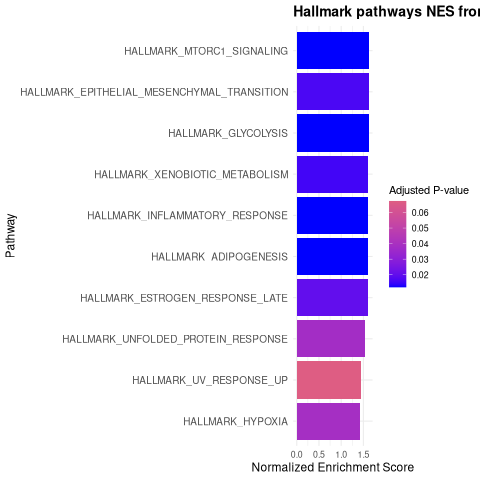

In [148]:
%%R

# Create the ggplot with a color scale for padj
ggplot(fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

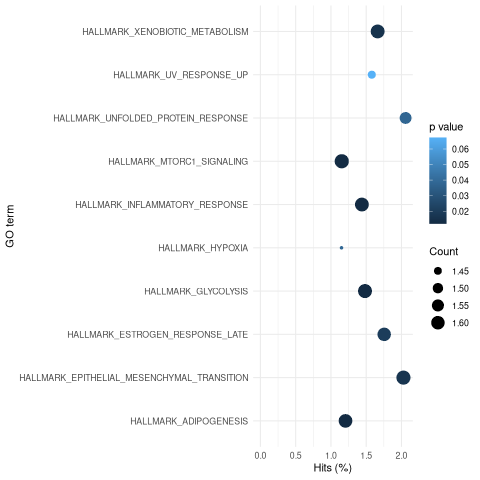

In [149]:
%%R

# Calculate hits percentage (if 'numDEInCat' and 'numInCat' equivalent are 'NES' and 'size')
fgseaResSignificant <- fgseaResSignificant %>%
  mutate(hitsPerc = NES * 100 / size)

# Ensure the columns 'padj' and 'NES' are present for the plot
fgseaResSignificant <- fgseaResSignificant %>%
  rename(term = pathway, over_represented_pvalue = padj, numDEInCat = NES)

# Create the plot
ggplot(fgseaResSignificant, aes(x = hitsPerc, y = term, colour = over_represented_pvalue, size = numDEInCat)) +
  geom_point() +
  expand_limits(x = 0) +
  labs(x = "Hits (%)", y = "GO term", colour = "p value", size = "Count") +
  theme_minimal()

#https://bioinformatics-core-shared-training.github.io/cruk-summer-school-2018/RNASeq2018/html/06_Gene_set_testing.nb.html

In [150]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.1, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                      padj   NES  size
  <chr>                                       <dbl> <dbl> <int>
1 HALLMARK_MTORC1_SIGNALING                  0.0119  1.63   141
2 HALLMARK_GLYCOLYSIS                        0.0119  1.62   109
3 HALLMARK_INFLAMMATORY_RESPONSE             0.0119  1.61   112
4 HALLMARK_ADIPOGENESIS                      0.0119  1.60   133
5 HALLMARK_XENOBIOTIC_METABOLISM             0.0156  1.61    97
6 HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION 0.0166  1.62    80


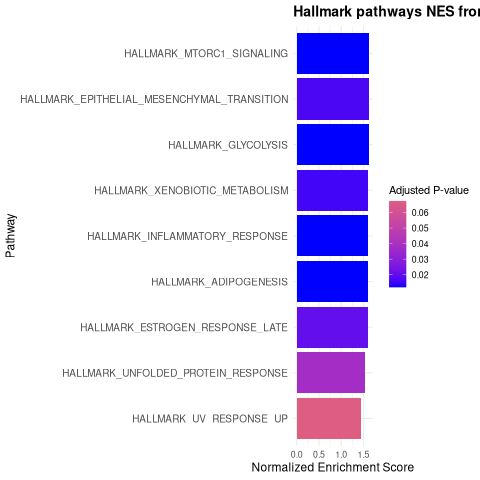

In [151]:
%%R

# Filter fgseaResSignificant to include only the main pathways from collapsedPathways
filtered_fgseaResSignificant <- fgseaResSignificant %>%
  filter(pathway %in% collapsedPathways$mainPathways)

# Create the ggplot with a color scale for padj
ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

In [152]:
%%R

# Remove "HALLMARK_" prefix from the 'pathway' column
filtered_fgseaResSignificant$pathway <- gsub("^HALLMARK_", "", filtered_fgseaResSignificant$pathway)

# View the updated heatmap_df
head(filtered_fgseaResSignificant)

# A tibble: 6 × 4
  pathway                             padj   NES  size
  <chr>                              <dbl> <dbl> <int>
1 MTORC1_SIGNALING                  0.0119  1.63   141
2 GLYCOLYSIS                        0.0119  1.62   109
3 INFLAMMATORY_RESPONSE             0.0119  1.61   112
4 ADIPOGENESIS                      0.0119  1.60   133
5 XENOBIOTIC_METABOLISM             0.0156  1.61    97
6 EPITHELIAL_MESENCHYMAL_TRANSITION 0.0166  1.62    80


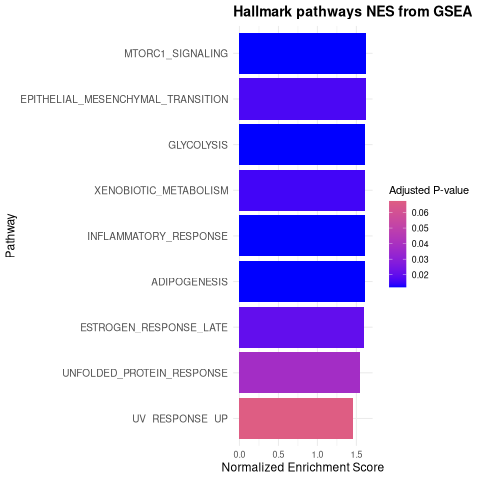

In [153]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/MOL_AL_hallmark_pathways_NES_GSEA.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

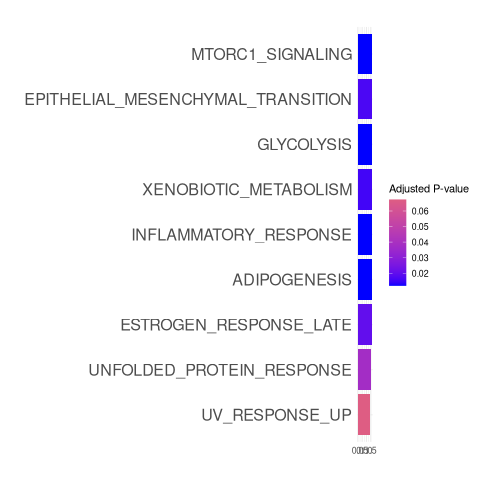

In [154]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "", y = "",
       title = "") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 16),
    axis.title = element_text(size = 16),
    plot.title = element_text(size = 16, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/MOL_CIL_hallmark_pathways_NES_GSEA2.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

In [155]:
%%R

fgsea_MOL2_significant <- as.data.frame(fgsea_MOL2_significant)

In [156]:
%%R
library(data.table)
fwrite(fgsea_MOL2_significant, file = "./files/filtered_fgseaResSignificant_CIL_all_glmm_zscore_MG_noPVM.csv")

In [157]:
%%R
unique(fgsea_MOL2_significant$pathway)

 [1] "HALLMARK_ADIPOGENESIS"                     
 [2] "HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION"
 [3] "HALLMARK_ESTROGEN_RESPONSE_LATE"           
 [4] "HALLMARK_GLYCOLYSIS"                       
 [5] "HALLMARK_HYPOXIA"                          
 [6] "HALLMARK_INFLAMMATORY_RESPONSE"            
 [7] "HALLMARK_MTORC1_SIGNALING"                 
 [8] "HALLMARK_UNFOLDED_PROTEIN_RESPONSE"        
 [9] "HALLMARK_UV_RESPONSE_UP"                   
[10] "HALLMARK_XENOBIOTIC_METABOLISM"            


In [158]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_TNFA_SIGNALING_VIA_NFKB"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL2_significant[fgsea_MOL2_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

NULL


In [ ]:
%%R
# Filter genes_down_sorted for genes in leading_edge_genes
matching_genes <- genes_up_sorted[genes_up_sorted$gene %in% leading_edge_genes, ]

# Print the filtered data frame
print(matching_genes)

# Optionally, count the number of matching genes
num_matching_genes <- nrow(matching_genes)
cat("Number of matching genes found in genes_down_sorted:", num_matching_genes, "\n")

# RL_MOL

In [159]:
%%R

# Replace the file path with the actual path if the file is not in the current directory
df <- read.csv("./files/GLMM_full_results_with_quality_RLvWM_MG_noPVM_cleaned.csv")
head(df)  # Display the first few rows of the data frame to confirm it's loaded correctly

        gene   logFC_WM         se       pvalue convergence pdHess     logLik
1      CD163 -5.5281263 0.76128700 3.826696e-13           0   TRUE  -90.04537
2       PLD3 -0.5896574 0.08402610 2.257916e-12           0   TRUE  -96.05716
3 AC027031.2  0.6560231 0.09922342 3.802518e-11           0   TRUE  -74.89412
4    L3MBTL4  0.4073700 0.06149051 3.474247e-11           0   TRUE -119.89775
5   ARHGAP24  0.3314897 0.05372611 6.829354e-10           0   TRUE -162.14907
6    FAM149A  0.8666184 0.13984015 5.747370e-10           0   TRUE -144.10382
       AIC error          FDR status
1 198.0907    NA 2.315725e-09     OK
2 210.1143    NA 9.109186e-09     OK
3 167.7882    NA 9.204374e-08     OK
4 257.7955    NA 9.204374e-08     OK
5 342.2981    NA 8.436794e-07     OK
6 306.2076    NA 8.436794e-07     OK


In [160]:
%%R

df <- df %>% mutate(logFC_rev = logFC_WM * -1)

In [161]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_up <- df[df$FDR < 0.05 & df$logFC_rev > 0.585, ]
num_genes_up <- nrow(genes_up)

# Print the number of significant genes
print(num_genes_up)

genes_up_sorted <- genes_up[order(genes_up$logFC_rev, decreasing = TRUE), ]

# View the head of the significant genes data frame
head(genes_up_sorted)

[1] 309
        gene  logFC_WM       se       pvalue convergence pdHess    logLik
7       GFAP -6.182303 1.002522 6.970829e-10           0   TRUE -82.49926
81      AQP9 -6.176124 1.313914 2.594573e-06           0   TRUE -38.89270
811     THBD -5.951765 2.044191 3.596402e-03           0   TRUE -56.71396
34   FAM107A -5.814038 1.114625 1.826902e-07           0   TRUE -60.46605
384    KCNE1 -5.639877 1.622074 5.071454e-04           0   TRUE -59.84722
91  SLC16A10 -5.600332 1.223281 4.691680e-06           0   TRUE -81.10835
          AIC error          FDR status logFC_rev
7   182.99851    NA 8.436794e-07     OK  6.182303
81   95.78539    NA 3.171930e-04     OK  6.176124
811 131.42791    NA 4.442271e-02     OK  5.951765
34  138.93210    NA 4.913554e-05     OK  5.814038
384 137.69443    NA 1.303181e-02     OK  5.639877
91  180.21670    NA 5.209487e-04     OK  5.600332


In [162]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_down <- df[df$FDR < 0.05 & df$logFC_rev < -0.585, ]
num_genes_down <- nrow(genes_down)

# Print the number of significant genes
print(num_genes_down)

genes_down_sorted <- genes_down[order(genes_down$logFC_rev, decreasing = FALSE), ]

# View the head of the significant genes data frame
head(genes_down_sorted)

[1] 235
          gene logFC_WM        se       pvalue convergence pdHess     logLik
93         CKB 4.341343 0.9508050 4.972002e-06           0   TRUE  -67.62063
26     SLC18A1 4.105764 0.7473412 3.933132e-08           0   TRUE  -50.73668
172     CACNB2 4.059780 0.9882870 3.992803e-05           0   TRUE  -82.47421
98  AC008691.1 3.515930 0.7815039 6.829700e-06           0   TRUE -164.04206
112   KIAA1211 3.049784 0.6925015 1.062675e-05           0   TRUE  -60.91658
783       DNM1 2.866685 0.9781272 3.381023e-03           0   TRUE  -50.25068
         AIC error          FDR status logFC_rev
93  153.2413    NA 5.421274e-04     OK -4.341343
26  119.4734    NA 1.442506e-05     OK -4.105764
172 182.9484    NA 2.416245e-03     OK -4.059780
98  346.0841    NA 7.125850e-04     OK -3.515930
112 139.8332    NA 9.830250e-04     OK -3.049784
783 118.5014    NA 4.307423e-02     OK -2.866685


In [163]:
%%R

dim(df)

[1] 9714   12


In [164]:
%%R

my_genes <- df$gene
head(my_genes)

[1] "CD163"      "PLD3"       "AC027031.2" "L3MBTL4"    "ARHGAP24"  
[6] "FAM149A"   


In [165]:
%%R
# Check column names in the dataframe
colnames(df)

 [1] "gene"        "logFC_WM"    "se"          "pvalue"      "convergence"
 [6] "pdHess"      "logLik"      "AIC"         "error"       "FDR"        
[11] "status"      "logFC_rev"  


In [166]:
%%R

df <- df[!is.na(df$pvalue) & !is.na(df$logFC_rev), ]
dim(df)

[1] 9707   12


In [167]:
%%R

# Start with the original dataframe
clean_df <- df

# Replace p-values of exactly 0 with a very small number
# Using machine epsilon * 10 to avoid numerical issues
min_pvalue <- .Machine$double.eps * 10
clean_df$pvalue[clean_df$pvalue == 0] <- min_pvalue

# Calculate Z-score from unadjusted p-value and log fold change sign
# Z-score = qnorm(p/2, lower.tail=FALSE) * sign(logFC)
# Using p/2 for two-tailed test conversion
clean_df$z_score <- qnorm(clean_df$pvalue/2, lower.tail = FALSE) * sign(clean_df$logFC_rev)

# Create rankings for FGSEA
rankings <- clean_df$z_score
names(rankings) <- clean_df$gene

# Remove any remaining NA or infinite values that might have been created
rankings <- rankings[is.finite(rankings)]

# Sort the rankings in descending order
rankings <- sort(rankings, decreasing = TRUE)

# Optional: Check the distribution of your rankings
print(paste("Number of genes in ranking:", length(rankings)))
print(paste("Range of Z-scores:", round(min(rankings), 2), "to", round(max(rankings), 2)))
print(head(rankings, 10))  # Show top 10 genes

[1] "Number of genes in ranking: 9707"
[1] "Range of Z-scores: -6.62 to 7.26"
    CD163      PLD3      GFAP     CRTC3  SH3PXD2B     F13A1     TGFBI    IQGAP2 
 7.261553  7.017550  6.166749  6.116798  5.990987  5.972977  5.921371  5.796152 
LINC01505     ITGA4 
 5.763811  5.717633 


In [168]:
%%R

# Ensure the length of the gene column matches the length of rankings
length(df$gene) == length(rankings)

[1] TRUE


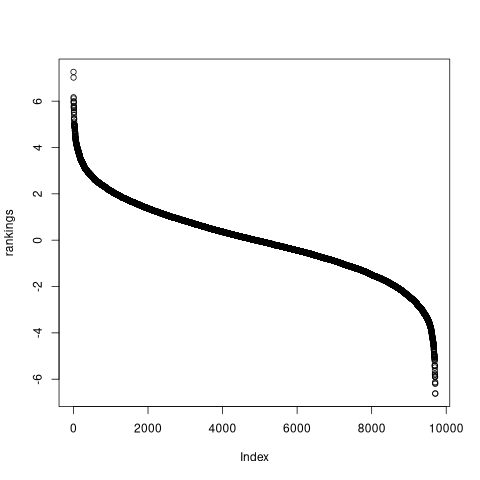

In [169]:
%%R

plot(rankings)

In [170]:
%%R

max(rankings)

[1] 7.261553


In [171]:
%%R

min(rankings)

[1] -6.624925


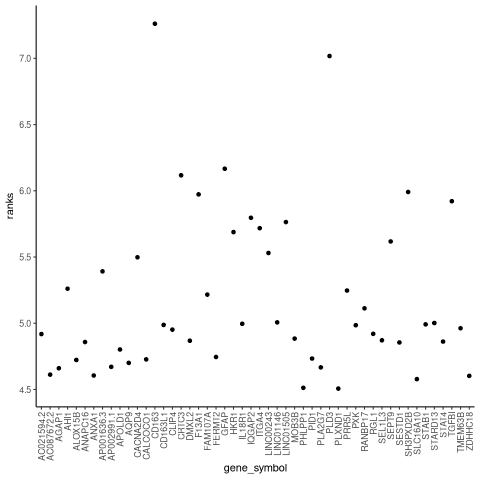

In [172]:
%%R

ggplot(data.frame(gene_symbol = names(rankings)[1:50], ranks = rankings[1:50]), aes(gene_symbol, ranks)) + 
    geom_point() +
    theme_classic() + 
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

## set up gene lists

In [173]:
%%R
fgsea_res <- fgsea(pathways = pathwaysH, 
                  stats    = rankings,
                  scoreType = 'std',
                  minSize  = 15,
                  maxSize  = 500)

In [174]:
%%R
fgsea_res

                                       pathway         pval         padj
                                        <char>        <num>        <num>
 1:                      HALLMARK_ADIPOGENESIS 3.688280e-02 1.555570e-01
 2:               HALLMARK_ALLOGRAFT_REJECTION 2.434457e-01 4.052399e-01
 3:                 HALLMARK_ANDROGEN_RESPONSE 5.741445e-01 6.393882e-01
 4:                      HALLMARK_ANGIOGENESIS 5.590551e-01 6.370628e-01
 5:                   HALLMARK_APICAL_JUNCTION 2.570356e-01 4.062822e-01
 6:                    HALLMARK_APICAL_SURFACE 2.760736e-01 4.186490e-01
 7:                         HALLMARK_APOPTOSIS 3.495327e-01 4.757529e-01
 8:              HALLMARK_BILE_ACID_METABOLISM 2.481061e-01 4.052399e-01
 9:           HALLMARK_CHOLESTEROL_HOMEOSTASIS 3.809558e-02 1.555570e-01
10:                       HALLMARK_COAGULATION 9.683426e-02 2.636044e-01
11:                        HALLMARK_COMPLEMENT 3.853594e-03 2.697516e-02
12:                        HALLMARK_DNA_REPAIR 8.60

In [175]:
%%R

dim(fgsea_res)

[1] 49  8


In [176]:
%%R
library(data.table)

#fwrite(fgsea_res, file = "./files/fgsea_RL_GvC_all.csv")

In [177]:
%%R

# Filter for significant results with padj < 0.05
fgsea_MOL4_significant <- fgsea_res %>% filter(padj < 0.1)
dim(fgsea_MOL4_significant)

[1] 10  8


In [178]:
%%R

head(fgsea_MOL4_significant)

                                      pathway         pval         padj
                                       <char>        <num>        <num>
1:                        HALLMARK_COMPLEMENT 3.853594e-03 2.697516e-02
2: HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION 3.646902e-03 2.697516e-02
3:                        HALLMARK_GLYCOLYSIS 1.777028e-06 4.353718e-05
4:                           HALLMARK_HYPOXIA 1.005871e-08 4.928768e-07
5:               HALLMARK_IL2_STAT5_SIGNALING 6.724251e-03 3.593663e-02
6:             HALLMARK_INFLAMMATORY_RESPONSE 7.132660e-04 1.165001e-02
     log2err        ES      NES  size
       <num>     <num>    <num> <int>
1: 0.4317077 0.3382690 1.517940   123
2: 0.4317077 0.3794571 1.577899    83
3: 0.6435518 0.4627166 2.027610   108
4: 0.7477397 0.5044854 2.225233   115
5: 0.4070179 0.3356717 1.495745   122
6: 0.4772708 0.3671797 1.628659   119
                                    leadingEdge
                                         <list>
1:       PLA2G7,CBLB,FYN

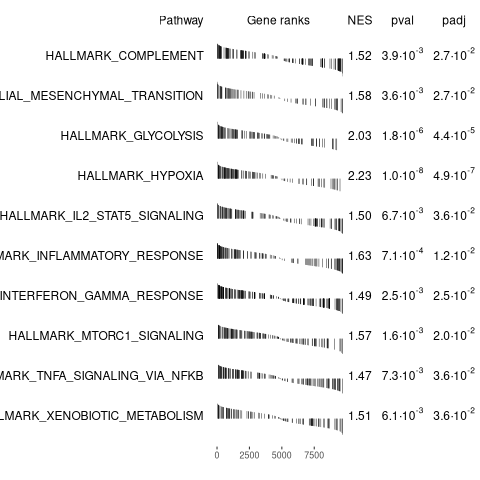

In [179]:
%%R

plotGseaTable(pathwaysH[fgsea_MOL4_significant$pathway], 
              rankings, 
              fgsea_MOL4_significant, 
              gseaParam = 0.5)

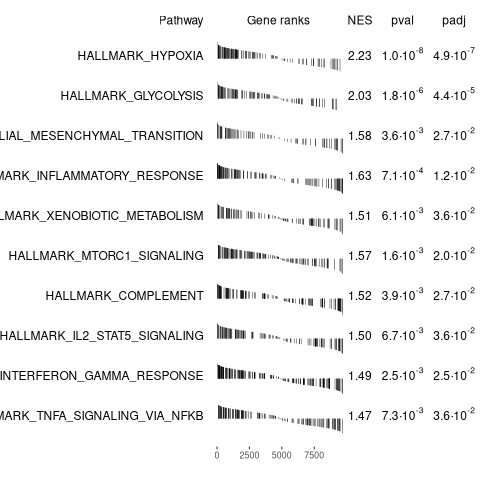

In [180]:
%%R

topUp <- fgsea_MOL4_significant %>% 
    filter(ES > 0) %>% 
    top_n(10, wt=-padj)

topDown <- fgsea_MOL4_significant %>% 
    filter(ES < 0) %>% 
    top_n(10, wt=-padj)

topPathways <- bind_rows(topUp, topDown) %>% 
    arrange(-ES)

plotGseaTable(pathwaysH[topPathways$pathway], 
              rankings, 
              fgsea_MOL4_significant, 
              gseaParam = 0.5)

In [181]:
%%R

collapsedPathways <- collapsePathways(fgsea_MOL4_significant[order(pval)][padj < 0.1], 
                                      pathwaysH, rankings)

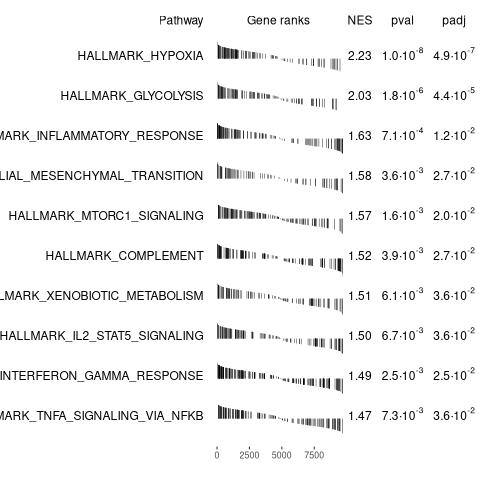

In [182]:
%%R

mainPathways <- fgsea_MOL4_significant[pathway %in% collapsedPathways$mainPathways][
                         order(-NES), pathway]
plotGseaTable(pathwaysH[mainPathways], rankings, fgsea_MOL4_significant, 
              gseaParam = 0.5)

In [183]:
%%R

fgseaResTidy <- fgsea_res %>%
  as_tibble() %>%
  arrange(desc(NES))

In [184]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.1, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                           padj   NES  size
  <chr>                                            <dbl> <dbl> <int>
1 HALLMARK_HYPOXIA                           0.000000493  2.23   115
2 HALLMARK_GLYCOLYSIS                        0.0000435    2.03   108
3 HALLMARK_INFLAMMATORY_RESPONSE             0.0117       1.63   119
4 HALLMARK_MTORC1_SIGNALING                  0.0198       1.57   138
5 HALLMARK_INTERFERON_GAMMA_RESPONSE         0.0248       1.49   151
6 HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION 0.0270       1.58    83


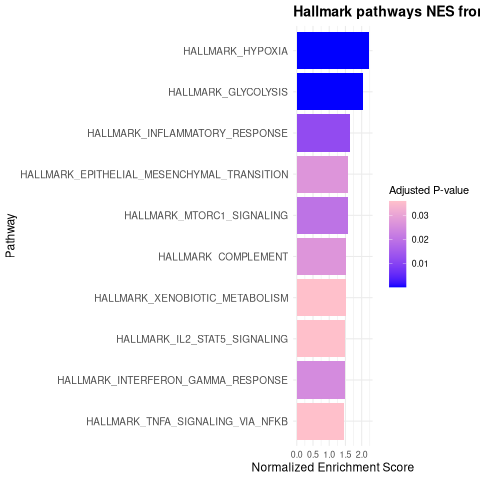

In [185]:
%%R

# Create the ggplot with a color scale for padj
ggplot(fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "blue", high = "pink", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

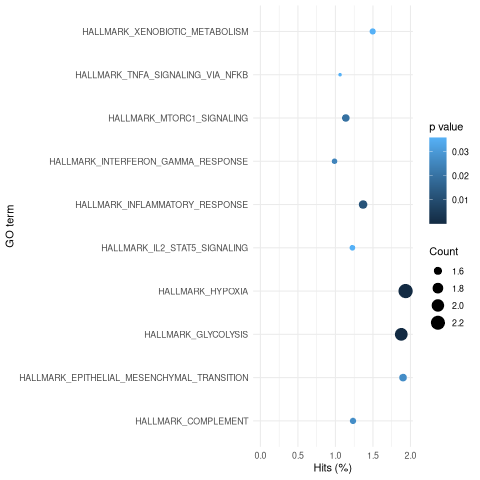

In [186]:
%%R

# Calculate hits percentage (if 'numDEInCat' and 'numInCat' equivalent are 'NES' and 'size')
fgseaResSignificant <- fgseaResSignificant %>%
  mutate(hitsPerc = NES * 100 / size)

# Ensure the columns 'padj' and 'NES' are present for the plot
fgseaResSignificant <- fgseaResSignificant %>%
  rename(term = pathway, over_represented_pvalue = padj, numDEInCat = NES)

# Create the plot
ggplot(fgseaResSignificant, aes(x = hitsPerc, y = term, colour = over_represented_pvalue, size = numDEInCat)) +
  geom_point() +
  expand_limits(x = 0) +
  labs(x = "Hits (%)", y = "GO term", colour = "p value", size = "Count") +
  theme_minimal()

#https://bioinformatics-core-shared-training.github.io/cruk-summer-school-2018/RNASeq2018/html/06_Gene_set_testing.nb.html

In [187]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.1, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                           padj   NES  size
  <chr>                                            <dbl> <dbl> <int>
1 HALLMARK_HYPOXIA                           0.000000493  2.23   115
2 HALLMARK_GLYCOLYSIS                        0.0000435    2.03   108
3 HALLMARK_INFLAMMATORY_RESPONSE             0.0117       1.63   119
4 HALLMARK_MTORC1_SIGNALING                  0.0198       1.57   138
5 HALLMARK_INTERFERON_GAMMA_RESPONSE         0.0248       1.49   151
6 HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION 0.0270       1.58    83


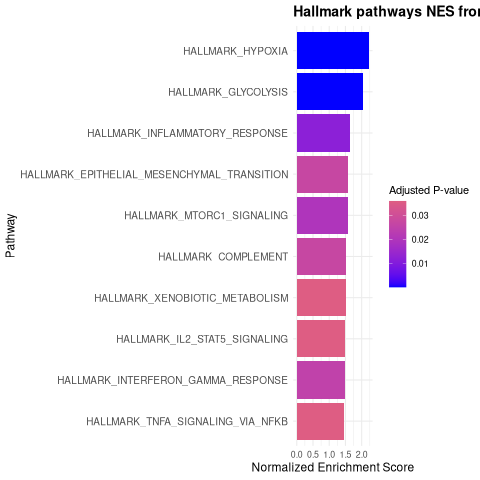

In [188]:
%%R

# Filter fgseaResSignificant to include only the main pathways from collapsedPathways
filtered_fgseaResSignificant <- fgseaResSignificant %>%
  filter(pathway %in% collapsedPathways$mainPathways)

# Create the ggplot with a color scale for padj
ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )


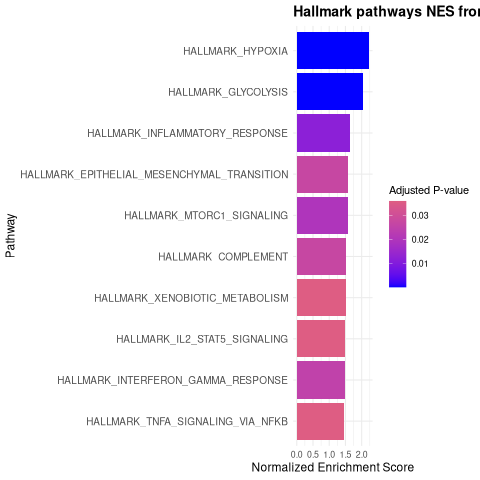

In [189]:
%%R

# Create the ggplot
plot <- # Create the ggplot with a color scale for padj
ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/MOL_RL_reduced_hallmark_pathways_NES_GSEA.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

In [190]:
%%R

# Remove "HALLMARK_" prefix from the 'pathway' column
filtered_fgseaResSignificant$pathway <- gsub("^HALLMARK_", "", filtered_fgseaResSignificant$pathway)

# View the updated heatmap_df
head(filtered_fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                  padj   NES  size
  <chr>                                   <dbl> <dbl> <int>
1 HYPOXIA                           0.000000493  2.23   115
2 GLYCOLYSIS                        0.0000435    2.03   108
3 INFLAMMATORY_RESPONSE             0.0117       1.63   119
4 MTORC1_SIGNALING                  0.0198       1.57   138
5 INTERFERON_GAMMA_RESPONSE         0.0248       1.49   151
6 EPITHELIAL_MESENCHYMAL_TRANSITION 0.0270       1.58    83


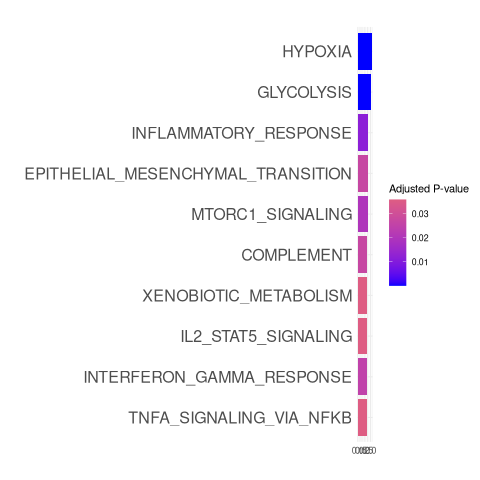

In [191]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "", y = "",
       title = "") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 16),
    axis.title = element_text(size = 16),
    plot.title = element_text(size = 16, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/MOL_RL_reduced_hallmark_pathways_NES_GSEA2.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

In [192]:
%%R

class(fgsea_MOL4_significant)

[1] "data.table" "data.frame"


In [193]:
%%R

fgsea_MOL4_significant <- as.data.frame(fgsea_MOL4_significant)

In [194]:
%%R
library(data.table)
fwrite(fgsea_MOL4_significant, file = "./files/filtered_fgseaResSignificant_RL_all_glmm_zscore_MG_noPVM.csv")

In [195]:
%%R
unique(fgsea_MOL4_significant$pathway)

 [1] "HALLMARK_COMPLEMENT"                       
 [2] "HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION"
 [3] "HALLMARK_GLYCOLYSIS"                       
 [4] "HALLMARK_HYPOXIA"                          
 [5] "HALLMARK_IL2_STAT5_SIGNALING"              
 [6] "HALLMARK_INFLAMMATORY_RESPONSE"            
 [7] "HALLMARK_INTERFERON_GAMMA_RESPONSE"        
 [8] "HALLMARK_MTORC1_SIGNALING"                 
 [9] "HALLMARK_TNFA_SIGNALING_VIA_NFKB"          
[10] "HALLMARK_XENOBIOTIC_METABOLISM"            


In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_HYPOXIA"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL4_significant[fgsea_MOL4_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R
# Filter genes_down_sorted for genes in leading_edge_genes
matching_genes <- genes_up_sorted[genes_up_sorted$gene %in% leading_edge_genes, ]

# Print the filtered data frame
print(matching_genes)

# Optionally, count the number of matching genes
num_matching_genes <- nrow(matching_genes)
cat("Number of matching genes found in genes_down_sorted:", num_matching_genes, "\n")

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_TNFA_SIGNALING_VIA_NFKB"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL4_significant[fgsea_MOL4_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R
# Filter genes_down_sorted for genes in leading_edge_genes
matching_genes <- genes_up_sorted[genes_up_sorted$gene %in% leading_edge_genes, ]

# Print the filtered data frame
print(matching_genes)

# Optionally, count the number of matching genes
num_matching_genes <- nrow(matching_genes)
cat("Number of matching genes found in genes_down_sorted:", num_matching_genes, "\n")

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_CHOLESTEROL_HOMEOSTASIS"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL4_significant[fgsea_MOL4_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R
# Filter genes_down_sorted for genes in leading_edge_genes
matching_genes <- genes_up_sorted[genes_up_sorted$gene %in% leading_edge_genes, ]

# Print the filtered data frame
print(matching_genes)

# Optionally, count the number of matching genes
num_matching_genes <- nrow(matching_genes)
cat("Number of matching genes found in genes_down_sorted:", num_matching_genes, "\n")

# CREATE A COMBINED HEATMAP-- NEW NES colored

In [196]:
%%R

# Load the data.table package
library(data.table)

# Read the files back into R
NAWM_df <- fread("./files/filtered_fgseaResSignificant_NAWM_all_glmm_zscore_MG_noPVM.csv")
AL_df <- fread("./files/filtered_fgseaResSignificant_AL_all_glmm_zscore_MG_noPVM.csv")
CAL_df <- fread("./files/filtered_fgseaResSignificant_CAL_all_glmm_zscore_MG_noPVM.csv")
CIL_df <- fread("./files/filtered_fgseaResSignificant_CIL_all_glmm_zscore_MG_noPVM.csv")
RL_df <- fread("./files/filtered_fgseaResSignificant_RL_all_glmm_zscore_MG_noPVM.csv")

In [197]:
%%R
print(dim(NAWM_df))
print(dim(AL_df))
print(dim(CAL_df))
print(dim(CIL_df))
print(dim(RL_df))

[1] 19  8
[1] 10  8
[1] 9 8
[1] 10  8
[1] 10  8


In [198]:
%%R
# For detailed differences in column names (if any)
list_columns <- list(
    NAWM_df = colnames(NAWM_df),
    AL_df = colnames(AL_df),
    CAL_df = colnames(CAL_df),
    CIL_df = colnames(CIL_df),
    RL_df = colnames(RL_df)
)

print(list_columns)

$NAWM_df
[1] "pathway"     "pval"        "padj"        "log2err"     "ES"         
[6] "NES"         "size"        "leadingEdge"

$AL_df
[1] "pathway"     "pval"        "padj"        "log2err"     "ES"         
[6] "NES"         "size"        "leadingEdge"

$CAL_df
[1] "pathway"     "pval"        "padj"        "log2err"     "ES"         
[6] "NES"         "size"        "leadingEdge"

$CIL_df
[1] "pathway"     "pval"        "padj"        "log2err"     "ES"         
[6] "NES"         "size"        "leadingEdge"

$RL_df
[1] "pathway"     "pval"        "padj"        "log2err"     "ES"         
[6] "NES"         "size"        "leadingEdge"



In [199]:
%%R

# Subset the data frames to include only pathway, padj, NES, and size
subset_columns <- c("pathway", "NES", "padj")

NAWM_subset <- NAWM_df[, ..subset_columns]
AL_subset <- AL_df[, ..subset_columns]
CAL_subset <- CAL_df[, ..subset_columns]
CIL_subset <- CIL_df[, ..subset_columns]
RL_subset <- RL_df[, ..subset_columns]

In [200]:
%%R

# Combine the 'pathway' columns from all the data frames
all_pathways <- unique(c(NAWM_df$pathway, AL_df$pathway, CAL_df$pathway, CIL_df$pathway, RL_df$pathway))

# Verify the unique pathways
print(head(all_pathways))

# Check the total number of unique pathways
length(all_pathways)

[1] "HALLMARK_ADIPOGENESIS"                     
[2] "HALLMARK_ALLOGRAFT_REJECTION"              
[3] "HALLMARK_APOPTOSIS"                        
[4] "HALLMARK_COAGULATION"                      
[5] "HALLMARK_COMPLEMENT"                       
[6] "HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION"
[1] 25


In [201]:
%%R
# Function to ensure each data frame includes all pathways and fills missing ones with NaN
fill_missing_pathways <- function(df, all_pathways) {
  # Identify pathways that are missing in the current data frame
  missing_pathways <- setdiff(all_pathways, df$pathway)
  
  # Create a data frame with missing pathways, NES and padj set to NaN
  missing_data <- data.frame(pathway = missing_pathways, 
                             NES = rep(NaN, length(missing_pathways)), 
                             padj = rep(NaN, length(missing_pathways)))
  
  # Combine the original data frame with the missing pathways
  df <- rbind(df[, c("pathway", "NES", "padj")], missing_data)
  
  # Sort by pathway to maintain a consistent order
  df <- df[order(df$pathway), ]
  
  return(df)
}

# List of all unique pathways
all_pathways <- unique(c(AL_df$pathway, CAL_df$pathway, CIL_df$pathway, RL_df$pathway))

# Apply the function to all data frames
NAWM_filtered <- fill_missing_pathways(NAWM_subset, all_pathways)
AL_filtered <- fill_missing_pathways(AL_subset, all_pathways)
CAL_filtered <- fill_missing_pathways(CAL_subset, all_pathways)
CIL_filtered <- fill_missing_pathways(CIL_subset, all_pathways)
RL_filtered <- fill_missing_pathways(RL_subset, all_pathways)

In [202]:
%%R
NAWM_filtered$condition <- "NAWM"
AL_filtered$condition <- "AL"
CAL_filtered$condition <- "CAL"
CIL_filtered$condition <- "CIL"
RL_filtered$condition <- "RL"

# Combine all datasets into a single dataframe
combined_df <- rbind(NAWM_filtered, AL_filtered, CAL_filtered, CIL_filtered, RL_filtered)

# Verify the structure
head(combined_df)

                                      pathway      NES         padj condition
                                       <char>    <num>        <num>    <char>
1:                      HALLMARK_ADIPOGENESIS 1.437204 0.0571814359      NAWM
2:               HALLMARK_ALLOGRAFT_REJECTION 1.443434 0.0529752834      NAWM
3:                         HALLMARK_APOPTOSIS 1.421484 0.0737504155      NAWM
4:                       HALLMARK_COAGULATION 1.896754 0.0035474436      NAWM
5:                        HALLMARK_COMPLEMENT 1.930358 0.0001677444      NAWM
6: HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION 1.947286 0.0001677444      NAWM


In [203]:
%%R
dim(combined_df)

[1] 105   4


In [204]:
%%R

# Remove "HALLMARK_" prefix from the 'pathway' column
combined_df$pathway <- gsub("^HALLMARK_", "", combined_df$pathway)

# View the updated heatmap_df
head(combined_df)

                             pathway      NES         padj condition
                              <char>    <num>        <num>    <char>
1:                      ADIPOGENESIS 1.437204 0.0571814359      NAWM
2:               ALLOGRAFT_REJECTION 1.443434 0.0529752834      NAWM
3:                         APOPTOSIS 1.421484 0.0737504155      NAWM
4:                       COAGULATION 1.896754 0.0035474436      NAWM
5:                        COMPLEMENT 1.930358 0.0001677444      NAWM
6: EPITHELIAL_MESENCHYMAL_TRANSITION 1.947286 0.0001677444      NAWM


In [205]:
%%R
head(combined_df)

                             pathway      NES         padj condition
                              <char>    <num>        <num>    <char>
1:                      ADIPOGENESIS 1.437204 0.0571814359      NAWM
2:               ALLOGRAFT_REJECTION 1.443434 0.0529752834      NAWM
3:                         APOPTOSIS 1.421484 0.0737504155      NAWM
4:                       COAGULATION 1.896754 0.0035474436      NAWM
5:                        COMPLEMENT 1.930358 0.0001677444      NAWM
6: EPITHELIAL_MESENCHYMAL_TRANSITION 1.947286 0.0001677444      NAWM


In [206]:
%%R
tail(combined_df)

                           pathway      NES       padj condition
                            <char>    <num>      <num>    <char>
1:                     P53_PATHWAY      NaN        NaN        RL
2: REACTIVE_OXYGEN_SPECIES_PATHWAY      NaN        NaN        RL
3:         TNFA_SIGNALING_VIA_NFKB 1.465611 0.03593663        RL
4:       UNFOLDED_PROTEIN_RESPONSE      NaN        NaN        RL
5:                  UV_RESPONSE_UP      NaN        NaN        RL
6:           XENOBIOTIC_METABOLISM 1.511325 0.03593663        RL


In [207]:
%%R

# Transform padj to -log10 for better visualization
combined_df$log_padj <- -log10(combined_df$padj)

In [208]:
%%R

dim(combined_df)

[1] 105   5


In [209]:
%%R

head(combined_df, 20)

                              pathway       NES         padj condition log_padj
                               <char>     <num>        <num>    <char>    <num>
 1:                      ADIPOGENESIS  1.437204 0.0571814359      NAWM 1.242745
 2:               ALLOGRAFT_REJECTION  1.443434 0.0529752834      NAWM 1.275927
 3:                         APOPTOSIS  1.421484 0.0737504155      NAWM 1.132236
 4:                       COAGULATION  1.896754 0.0035474436      NAWM 2.450084
 5:                        COMPLEMENT  1.930358 0.0001677444      NAWM 3.775352
 6: EPITHELIAL_MESENCHYMAL_TRANSITION  1.947286 0.0001677444      NAWM 3.775352
 7:            ESTROGEN_RESPONSE_LATE  1.410489 0.0714280301      NAWM 1.146131
 8:             FATTY_ACID_METABOLISM  1.387035 0.0929781748      NAWM 1.031619
 9:                        GLYCOLYSIS       NaN          NaN      NAWM      NaN
10:                           HYPOXIA       NaN          NaN      NAWM      NaN
11:               IL2_STAT5_SIGNALING   

In addition: Warning message:
Removed 47 rows containing missing values or values outside the scale range
(`geom_point()`). 


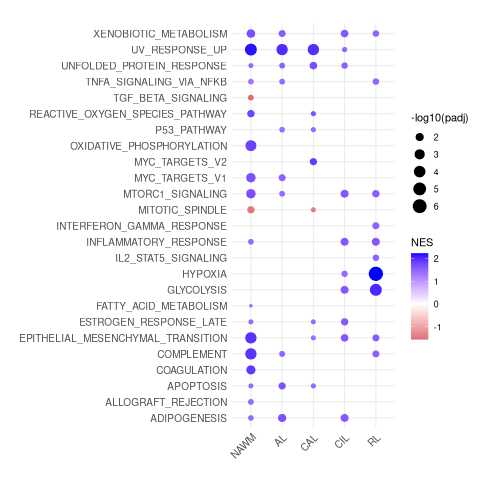

In [210]:
%%R

library(ggplot2)

# Set the factor levels for conditions to control the order
combined_df$condition <- factor(combined_df$condition, 
                                 levels = c("NAWM", "AL", "CAL", "CIL", "RL"))

# Create the dotplot with switched axes and assign to heatmap_plot
heatmap_plot <- ggplot(combined_df, aes(y = pathway, x = condition, size = log_padj, color = NES)) +
  geom_point() +
  scale_color_gradient2(low = "#c32148", mid = "white", high = "#0000FF", midpoint = 0) +
  theme_minimal() +
  theme(axis.text.y = element_text(size = 10), # Adjust pathway text size for readability
        axis.text.x = element_text(angle = 45, hjust = 1, size = 10)) + # Adjust condition text
  labs(x = "", y = "", 
       size = "-log10(padj)", color = "NES", 
       title = "")

# Show the plot
print(heatmap_plot)

In [211]:
%%R

# Remove rows with missing or NaN values in `log_padj` or `NES`
filtered_df <- combined_df[!is.na(combined_df$log_padj) & !is.na(combined_df$NES), ]
head(filtered_df)

                             pathway      NES         padj condition log_padj
                              <char>    <num>        <num>    <fctr>    <num>
1:                      ADIPOGENESIS 1.437204 0.0571814359      NAWM 1.242745
2:               ALLOGRAFT_REJECTION 1.443434 0.0529752834      NAWM 1.275927
3:                         APOPTOSIS 1.421484 0.0737504155      NAWM 1.132236
4:                       COAGULATION 1.896754 0.0035474436      NAWM 2.450084
5:                        COMPLEMENT 1.930358 0.0001677444      NAWM 3.775352
6: EPITHELIAL_MESENCHYMAL_TRANSITION 1.947286 0.0001677444      NAWM 3.775352


In [212]:
%%R
dim(filtered_df)

[1] 58  5


In [216]:
%%R

# Count how many conditions each pathway is "up" in (NES > 0)
pathway_order <- filtered_df %>%
  group_by(pathway) %>%
  summarise(
    n_up = sum(NES > 0),
    mean_NES = mean(NES, na.rm = TRUE)
  ) %>%
  arrange(desc(n_up), desc(mean_NES))

# Print ordered list of pathways with counts
print(pathway_order)

# Or, if you just want the ordered names:
ordered_pathways <- pathway_order$pathway
print(ordered_pathways)

# Update factor levels for plotting
filtered_df <- filtered_df %>%
  mutate(pathway = factor(pathway, levels = ordered_pathways))

# A tibble: 25 × 3
   pathway                            n_up mean_NES
   <chr>                             <int>    <dbl>
 1 UV_RESPONSE_UP                        4     1.90
 2 EPITHELIAL_MESENCHYMAL_TRANSITION     4     1.64
 3 XENOBIOTIC_METABOLISM                 4     1.60
 4 MTORC1_SIGNALING                      4     1.58
 5 UNFOLDED_PROTEIN_RESPONSE             4     1.55
 6 COMPLEMENT                            3     1.65
 7 ADIPOGENESIS                          3     1.57
 8 INFLAMMATORY_RESPONSE                 3     1.57
 9 APOPTOSIS                             3     1.50
10 ESTROGEN_RESPONSE_LATE                3     1.47
# ℹ 15 more rows
# ℹ Use `print(n = ...)` to see more rows
 [1] "UV_RESPONSE_UP"                    "EPITHELIAL_MESENCHYMAL_TRANSITION"
 [3] "XENOBIOTIC_METABOLISM"             "MTORC1_SIGNALING"                 
 [5] "UNFOLDED_PROTEIN_RESPONSE"         "COMPLEMENT"                       
 [7] "ADIPOGENESIS"                      "INFLAMMATORY_RESPONSE"   

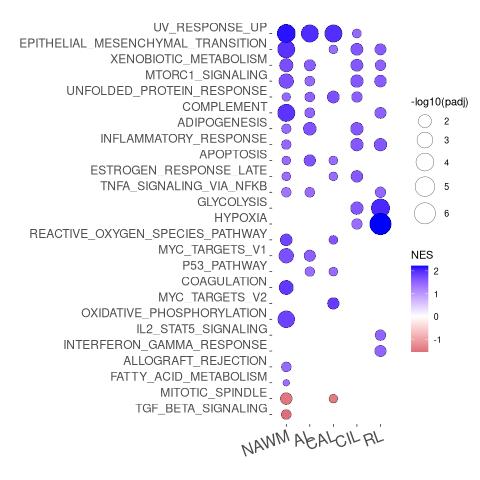

In [217]:
%%R

# Create the dotplot with adjustments
heatmap_plot <- ggplot(filtered_df, aes(y = pathway, x = condition, size = log_padj, fill = NES)) +
  geom_point(shape = 21, stroke = 0.2, color = "black") + # Add thin black outline to dots
  scale_fill_gradient2(low = "#c32148", mid = "white", high = "#0000FF", midpoint = 0) +
  scale_size_continuous(range = c(3, 10)) + # Increase size of dots (min=3, max=10)
  scale_y_discrete(limits = rev(levels(factor(filtered_df$pathway))),  # Reverse the y-axis order if needed
                   labels = function(x) paste0(x, "\n")) + # Add line breaks for extra vertical space
  theme_minimal() +
  theme(
    panel.grid = element_blank(), # Remove grid lines
    axis.text.y = element_text(size = 12), # Add vertical spacing for y-axis text
    axis.text.x = element_text(angle = 20, hjust = 1, size = 16, vjust = 1), # Adjust x-axis text spacing
    axis.ticks = element_line(linewidth = 0.3) # Adjust x-axis ticks with `linewidth`
  ) +
  labs(
    x = "", 
    y = "", 
    size = "-log10(padj)", 
    fill = "NES", 
    title = ""
  )

# Display the plot
print(heatmap_plot)

In [222]:
%%R

# Define the desired order for the pathways
desired_pathway_order <- c(
    "UV_RESPONSE_UP",
    "UNFOLDED_PROTEIN_RESPONSE",
    "EPITHELIAL_MESENCHYMAL_TRANSITION",
    "MTORC1_SIGNALING",
    "XENOBIOTIC_METABOLISM",
    "APOPTOSIS",
    "ADIPOGENESIS",
    "COMPLEMENT",
    "TNFA_SIGNALING_VIA_NFKB",
    "ESTROGEN_RESPONSE_LATE",
    "INFLAMMATORY_RESPONSE",
    "MYC_TARGETS_V1",
    "REACTIVE_OXYGEN_SPECIES_PATHWAY",
    "P53_PATHWAY",
    "HYPOXIA",
    "GLYCOLYSIS",
    "OXIDATIVE_PHOSPHORYLATION",
    "COAGULATION",
    "ALLOGRAFT_REJECTION",
    "FATTY_ACID_METABOLISM",
    "MYC_TARGETS_V2",
    "INTERFERON_GAMMA_RESPONSE",
    "IL2_STAT5_SIGNALING",
    "MITOTIC_SPINDLE",
    "TGF_BETA_SIGNALING"
)

# Reorder the 'pathway' column in filtered_df
filtered_df$pathway <- factor(filtered_df$pathway, levels = desired_pathway_order)

# Verify the order
print(levels(filtered_df$pathway))

 [1] "UV_RESPONSE_UP"                    "UNFOLDED_PROTEIN_RESPONSE"        
 [3] "EPITHELIAL_MESENCHYMAL_TRANSITION" "MTORC1_SIGNALING"                 
 [5] "XENOBIOTIC_METABOLISM"             "APOPTOSIS"                        
 [7] "ADIPOGENESIS"                      "COMPLEMENT"                       
 [9] "TNFA_SIGNALING_VIA_NFKB"           "ESTROGEN_RESPONSE_LATE"           
[11] "INFLAMMATORY_RESPONSE"             "MYC_TARGETS_V1"                   
[13] "REACTIVE_OXYGEN_SPECIES_PATHWAY"   "P53_PATHWAY"                      
[15] "HYPOXIA"                           "GLYCOLYSIS"                       
[17] "OXIDATIVE_PHOSPHORYLATION"         "COAGULATION"                      
[19] "ALLOGRAFT_REJECTION"               "FATTY_ACID_METABOLISM"            
[21] "MYC_TARGETS_V2"                    "INTERFERON_GAMMA_RESPONSE"        
[23] "IL2_STAT5_SIGNALING"               "MITOTIC_SPINDLE"                  
[25] "TGF_BETA_SIGNALING"               


In [223]:
%%R

# Dictionary to format pathway names
pathway_name_format <- list(
    "UV_RESPONSE_UP"                     = "UV Response (Up)",
    "UNFOLDED_PROTEIN_RESPONSE"          = "Unfolded Protein Response",
    "XENOBIOTIC_METABOLISM"              = "Xenobiotic Metabolism",
    "MTORC1_SIGNALING"                    = "MTORC1 Signaling",
    "EPITHELIAL_MESENCHYMAL_TRANSITION"  = "Epithelial-Mesenchymal Transition",
    "ADIPOGENESIS"                        = "Adipogenesis",
    "TNFA_SIGNALING_VIA_NFKB"            = "TNFα Signaling via NF-κB",
    "APOPTOSIS"                           = "Apoptosis",
    "ESTROGEN_RESPONSE_LATE"             = "Estrogen Response (Late)",
    "COMPLEMENT"                          = "Complement",
    "INFLAMMATORY_RESPONSE"               = "Inflammatory Response",
    "MYC_TARGETS_V1"                     = "MYC Targets V1",
    "REACTIVE_OXYGEN_SPECIES_PATHWAY"    = "Reactive Oxygen Species Pathway",
    "P53_PATHWAY"                         = "p53 Pathway",
    "HYPOXIA"                             = "Hypoxia",
    "GLYCOLYSIS"                          = "Glycolysis",
    "OXIDATIVE_PHOSPHORYLATION"          = "Oxidative Phosphorylation",
    "COAGULATION"                         = "Coagulation",
    "ALLOGRAFT_REJECTION"                 = "Allograft Rejection",
    "FATTY_ACID_METABOLISM"              = "Fatty Acid Metabolism",
    "MYC_TARGETS_V2"                      = "MYC Targets V2",
    "INTERFERON_GAMMA_RESPONSE"           = "Interferon-γ Response",
    "IL2_STAT5_SIGNALING"                 = "IL2/STAT5 Signaling",
    "MITOTIC_SPINDLE"                     = "Mitotic Spindle",
    "TGF_BETA_SIGNALING"                  = "TGF-β Signaling"
)

# Reverse the desired pathway order
reversed_pathway_order <- rev(desired_pathway_order)

# Add formatted pathway names to the dataframe
filtered_df$formatted_pathway <- pathway_name_format[as.character(filtered_df$pathway)]

# Reorder the 'formatted_pathway' column based on reversed pathway order
filtered_df$formatted_pathway <- factor(filtered_df$formatted_pathway, levels = pathway_name_format[reversed_pathway_order])

# Verify the new order
print(levels(filtered_df$formatted_pathway))

 [1] "TGF-β Signaling"                   "Mitotic Spindle"                  
 [3] "IL2/STAT5 Signaling"               "Interferon-γ Response"            
 [5] "MYC Targets V2"                    "Fatty Acid Metabolism"            
 [7] "Allograft Rejection"               "Coagulation"                      
 [9] "Oxidative Phosphorylation"         "Glycolysis"                       
[11] "Hypoxia"                           "p53 Pathway"                      
[13] "Reactive Oxygen Species Pathway"   "MYC Targets V1"                   
[15] "Inflammatory Response"             "Estrogen Response (Late)"         
[17] "TNFα Signaling via NF-κB"          "Complement"                       
[19] "Adipogenesis"                      "Apoptosis"                        
[21] "Xenobiotic Metabolism"             "MTORC1 Signaling"                 
[23] "Epithelial-Mesenchymal Transition" "Unfolded Protein Response"        
[25] "UV Response (Up)"                 


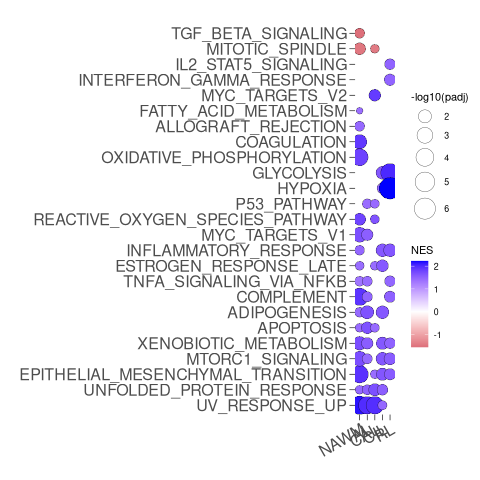

In [224]:
%%R

heatmap_plot <- ggplot(filtered_df, aes(y = pathway, x = condition, size = log_padj, fill = NES)) +
  geom_point(shape = 21, stroke = 0.2, color = "black") +
  scale_fill_gradient2(low = "#c32148", mid = "white", high = "#0000FF", midpoint = 0) +
  scale_size_continuous(range = c(3, 10)) +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.text.y = element_text(size = 16, vjust = 0.5),
    axis.text.x = element_text(angle = 30, hjust = 1, size = 16, vjust = 1),
    axis.ticks = element_line(linewidth = 0.3),
    axis.ticks.length = unit(0.2, "cm")
  ) +
  labs(
    x = "", 
    y = "", 
    size = "-log10(padj)", 
    fill = "NES", 
    title = ""
  )

print(heatmap_plot)

#ggsave("./figures/GSEA/heatmap_pathway_NES_padj_MOL_only_ordered.png", plot = heatmap_plot, dpi = 300, width = 7.5, height = 8)

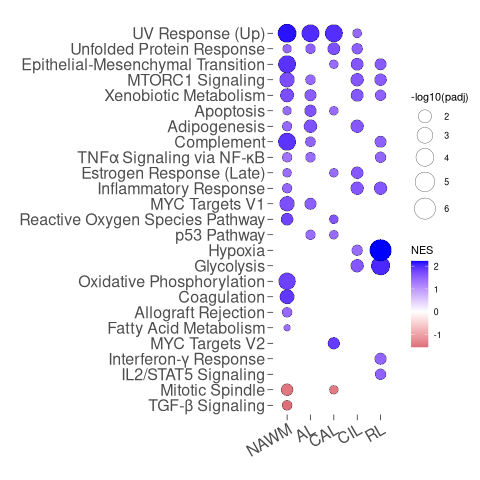

In [225]:
%%R

# Create the heatmap plot
heatmap_plot <- ggplot(filtered_df, aes(y = formatted_pathway, x = condition, size = log_padj, fill = NES)) +
  geom_point(shape = 21, stroke = 0.2, color = "black") +
  scale_fill_gradient2(low = "#c32148", mid = "white", high = "#0000FF", midpoint = 0) +
  scale_size_continuous(range = c(3, 10)) +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.text.y = element_text(size = 16, vjust = 0.5),
    axis.text.x = element_text(angle = 30, hjust = 1, size = 16, vjust = 1),
    axis.ticks = element_line(linewidth = 0.3),
    axis.ticks.length = unit(0.2, "cm")
  ) +
  labs(
    x = "", 
    y = "", 
    size = "-log10(padj)", 
    fill = "NES", 
    title = ""
  )

# Print the heatmap
print(heatmap_plot)

# Save the heatmap plot
ggsave("./figures/GSEA/heatmap_pathway_NES_padj_MG_ordered_glmm_revision.png", plot = heatmap_plot, dpi = 300, width = 7.5, height = 8)